In [1]:
import os
for v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'
# then numpy / xso / ssh imports BELOW this line

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

sys.path.insert(0, os.path.abspath('results/'))

In [5]:
print("="*98)
print("Three-way comparison: obs target vs sinusoidal model vs obs-Fourier model")
print("="*98)

OBS_KEYS = [('mcs','%7.3f'), ('mcs_med','%7.3f'), ('pico','%6.3f'), ('nano','%6.3f'),
            ('micro','%6.3f'), ('sumP','%6.3f'), ('Z200','%7.4f'), ('Z500','%8.5f'),
            ('N','%6.3f'), ('PP','%6.3f')]

for tag, alpha, rF, era_key in CHECKS:
    clim_sin = sinus[tag]
    clim_fou, _ = D['runs'][(era_key, rF)]
    obs_t = D['obs_t'][era_key]
    print(f"\n--- {tag}  |  r_F={rF}  |  era={era_key} ---")
    print(f"  {'metric':<9} {'obs_med':>8} {'obs_mn':>8}  {'sin':>8} {'Fou':>8}  "
          f"{'|Δsin|%':>9} {'|Δfou|%':>9}  closer (vs obs_med)")
    sin_wins = fou_wins = ties = 0
    for key, fmt in OBS_KEYS:
        om = obs_t['med'].get(key, np.nan)
        omn = obs_t['mean'].get(key, np.nan)
        sv = clim_sin.get(key, np.nan)
        fv = clim_fou.get(key, np.nan)
        # Distance to obs median (the Fig 4 box-plot reference)
        d_sin = abs(sv - om) / om * 100 if om else np.nan
        d_fou = abs(fv - om) / om * 100 if om else np.nan
        if not np.isfinite(d_sin) or not np.isfinite(d_fou):
            closer = '—'
        elif abs(d_sin - d_fou) < 0.5:
            closer = 'tie'; ties += 1
        elif d_sin < d_fou:
            closer = 'sin'; sin_wins += 1
        else:
            closer = 'Fou'; fou_wins += 1
        print(f"  {key:<9} {fmt%om:>8} {fmt%omn:>8}  {fmt%sv:>8} {fmt%fv:>8}  "
              f"{d_sin:>8.1f}% {d_fou:>8.1f}%   {closer}")
    print(f"  → tally: sin wins {sin_wins}  |  Fourier wins {fou_wins}  |  ties {ties}")

Three-way comparison: obs target vs sinusoidal model vs obs-Fourier model

--- post     (α=0)  |  r_F=0.1  |  era=post ---
  metric     obs_med   obs_mn       sin      Fou    |Δsin|%   |Δfou|%  closer (vs obs_med)
  mcs          2.318    4.668     3.281    3.152      41.6%     36.0%   Fou
  mcs_med        nan      nan     2.306    2.222       nan%      nan%   —
  pico         0.562    0.542     0.558    0.566       0.7%      0.7%   tie
  nano         0.272    0.267     0.248    0.244       8.9%     10.5%   sin
  micro        0.124    0.191     0.194    0.191      56.7%     54.0%   Fou
  sumP         0.459    0.581     0.468    0.468       1.9%      2.0%   tie
  Z200        0.0566   0.0660    0.0379   0.0363      33.1%     35.8%   sin
  Z500       0.03341  0.03712   0.00833  0.00829      75.1%     75.2%   tie
  N            0.959    1.235     0.852    0.768      11.2%     19.9%   sin
  PP           0.202    0.324     0.114    0.114      43.4%     43.6%   tie
  → tally: sin wins 3  |  Fo

In [ ]:
import warnings, time as _t, os
import numpy as np
import xarray as xr
import seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
from baseline_r0_seasonal_comps import _build_fourier_func
warnings.filterwarnings('ignore', message='Instability event')
warnings.filterwarnings('ignore', message='solve_ivp')

# === era anchors from obs (Fourier-smoothed) ============================
forc_obs = ssh.build_forcings(['pre+recovery', 'post'])
def _smooth(monthly, n=2):
    return _build_fourier_func(monthly, period=365.0, n_harmonics=n)(np.linspace(0, 365, 365))
def _char(monthly):
    s = _smooth(monthly)
    return float(s.mean()), float((s.max()-s.min())/2), int(np.argmax(s))
POST_FN_M, POST_FN_A, POST_FN_PHI = _char(forc_obs['post']['fn'])
PRE_FN_M,  PRE_FN_A,  _           = _char(forc_obs['pre+recovery']['fn'])
POST_DE_M, POST_DE_A, _           = _char(forc_obs['post']['de'])
PRE_DE_M,  PRE_DE_A,  _           = _char(forc_obs['pre+recovery']['de'])
POST_T_M,  POST_T_A,  _           = _char(forc_obs['post']['t'])
PRE_T_M,   PRE_T_A,   _           = _char(forc_obs['pre+recovery']['t'])
PHI      = POST_FN_PHI
MID_DOY  = np.array([15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349])

def sinusoidal_monthly(alpha):
    """Sinusoidal F_N, d_e, T anti-phase locked to F_N peak; linear interp post (α=0) → pre+rec (α=1).
    Returns 12 mid-month values (the harness Fourier-fits these to a continuous forcing)."""
    fn_m = POST_FN_M + alpha * (PRE_FN_M - POST_FN_M)
    fn_a = POST_FN_A + alpha * (PRE_FN_A - POST_FN_A)
    de_m = POST_DE_M + alpha * (PRE_DE_M - POST_DE_M)
    de_a = POST_DE_A + alpha * (PRE_DE_A - POST_DE_A)
    t_m  = POST_T_M  + alpha * (PRE_T_M  - POST_T_M)
    t_a  = POST_T_A  + alpha * (PRE_T_A  - POST_T_A)
    cos_md = np.cos(2*np.pi*(MID_DOY - PHI)/365)
    return {
        'fn': np.maximum(fn_m + fn_a * cos_md, 0.01),
        'de': np.maximum(de_m - de_a * cos_md, 5.0),
        't':  t_m - t_a * cos_md,
    }

# === scan axes ===========================================================
ALPHAS = np.linspace(-0.5, 2.0, 50)
R_F    = np.linspace(0.0, 0.6, 50)
print(f"α:   {ALPHAS[0]:.2f}–{ALPHAS[-1]:.2f}  (Δ={ALPHAS[1]-ALPHAS[0]:.3f}, n={len(ALPHAS)})")
print(f"r_F: {R_F[0]:.3f}–{R_F[-1]:.3f}  (Δ={R_F[1]-R_F[0]:.4f}, n={len(R_F)})")
print(f"tasks: {len(ALPHAS)*len(R_F)} = 2500")
print(f"SEASONAL_SOLVER_KWARGS: {ssh.SEASONAL_SOLVER_KWARGS}\n")

# === construct (settled) + per-task kwargs ==============================
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}

combos = [(a, rf) for a in ALPHAS for rf in R_F]
tasks  = [(dict(construct=spec,
                forcing=sinusoidal_monthly(a),
                fish_rate=float(rf),
                years=60, spinup=15,
                mP=0.0015, m_Z=0.1,
                grazing=GRZ, iv_overrides=IVO,
                return_traj=True),)
          for a, rf in combos]

# === result containers ==================================================
shape = (len(ALPHAS), len(R_F))
def _empty(*dims): return np.full((*shape, *dims), np.nan)

SCALAR_FIELDS = ['mcs', 'mcs_med', 'pico', 'nano', 'micro',
                 'sumP', 'sumZ', 'Z200', 'Z500', 'Z200_peak',
                 'N', 'PP', 'Export',
                 'cv_sumP', 'cv_sumZ', 'mcs_conv', 'minP', 'minZ', 'nan_frac']
CLIM_FIELDS   = ['mcs', 'pico', 'nano', 'micro', 'sumP', 'Z200', 'Z500', 'N', 'PP']
# r-dict key → storage name (r uses 'Ztot' for total zoo)
TRAJ_MAP = [('mcs','mcs'), ('pico','pico'), ('nano','nano'), ('micro','micro'),
            ('sumP','sumP'), ('Ztot','sumZ'),
            ('Z200','Z200'), ('Z500','Z500'),
            ('N','N'), ('PP','PP')]
TAIL_DAYS = 1000

scalars = {k: _empty() for k in SCALAR_FIELDS}
clims   = {k: _empty(12) for k in CLIM_FIELDS}
trajs   = {ds_name: _empty(TAIL_DAYS) for _, ds_name in TRAJ_MAP}
HASN    = np.zeros(shape, dtype=bool)

def on_result(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if not item['ok']:
        return
    clim, r = item['result']
    HASN[i, j] = bool(clim.get('has_nan', False))
    for f in SCALAR_FIELDS:
        scalars[f][i, j] = clim.get(f, np.nan)
    for f in CLIM_FIELDS:
        v = clim.get('clim_' + f)
        if v is not None and len(v) == 12:
            clims[f][i, j, :] = v
    if not HASN[i, j] and 't' in r and len(r['t']) >= TAIL_DAYS:
        for r_key, ds_name in TRAJ_MAP:
            if r_key in r:
                v = np.asarray(r[r_key])
                if len(v) == len(r['t']):
                    trajs[ds_name][i, j, :] = v[-TAIL_DAYS:]

# === run =================================================================
t0 = _t.perf_counter()
run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None,
                   on_result=on_result, tally_flags=['has_nan'],
                   label='fig5_sinusoidal_50x50',
                   maxtasksperchild=1)
wall = (_t.perf_counter() - t0) / 60
print(f"\nwall: {wall:.1f} min")
print(f"trips: {int(HASN.sum())}/{HASN.size}")
print(f"|conv-1| > 0.10: {int(np.nansum(np.abs(scalars['mcs_conv'] - 1) > 0.10))}/{HASN.size}")
for k in ('mcs_med', 'micro', 'cv_sumP', 'Z200'):
    print(f"  {k:10s} range: {np.nanmin(scalars[k]):.4f} – {np.nanmax(scalars[k]):.4f}")

# === save to netCDF ======================================================
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_alpha_sinusoidal_50x50_2026-06-26.nc')

ds = xr.Dataset(
    data_vars={
        **{k: (('alpha', 'rF'), scalars[k]) for k in SCALAR_FIELDS},
        **{f'clim_{k}': (('alpha', 'rF', 'month'), clims[k]) for k in CLIM_FIELDS},
        **{f'traj_{k}': (('alpha', 'rF', 'day'), trajs[k]) for _, k in TRAJ_MAP},
        'has_nan': (('alpha', 'rF'), HASN.astype(np.int8)),
    },
    coords={'alpha': ALPHAS, 'rF': R_F,
            'month': np.arange(1, 13),
            'day': np.arange(TAIL_DAYS)},
    attrs=dict(
        construct='maranon_ward (Marañón 2013 μ + Ward 2012 K_s)',
        grazing='Dutkiewicz 2020 Type III + omnivory',
        GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
        forcing='sinusoidal abstract — F_N, d_e, T anti-phase locked, linear interp post (α=0) ↔ pre+rec (α=1)',
        forcing_FN_mean_post=POST_FN_M, forcing_FN_mean_pre=PRE_FN_M,
        forcing_FN_amp_post=POST_FN_A,  forcing_FN_amp_pre=PRE_FN_A,
        forcing_de_mean_post=POST_DE_M, forcing_de_mean_pre=PRE_DE_M,
        forcing_de_amp_post=POST_DE_A,  forcing_de_amp_pre=PRE_DE_A,
        forcing_T_mean_post=POST_T_M,   forcing_T_mean_pre=PRE_T_M,
        forcing_T_amp_post=POST_T_A,    forcing_T_amp_pre=PRE_T_A,
        forcing_phase_day=PHI,
        years=60, spinup=15, tail_days=TAIL_DAYS,
        solver='tight RK45 (atol=1e-9, rtol=1e-6, max_step=1.0); scipy#10070 fix via maxtasksperchild=1',
        created='2026-06-26',
        notes='α=0 anchored to post obs (mean+amp); α=1 anchored to pre+rec obs (mean+amp). '
              'Era markers in (α, r_F) plane: post at (α=0, r_F=0.1); pre+rec at (α=1, r_F=0.5). '
              'See Ideas and Findings entries for the Fig 5 design context.',
    ),
)
ds.to_netcdf(nc_path)
print(f"\nsaved: {nc_path}  ({os.path.getsize(nc_path)/1e6:.1f} MB)")
print(f"reload: ds = xr.open_dataset('{nc_path}')")

In [3]:
import importlib, time as _t, os
import numpy as np, xarray as xr
import seasonal_scan_harness as ssh
import baseline_r0_seasonal_setups as br_seas
importlib.reload(br_seas); importlib.reload(ssh)
from xso.parscans import run_xso_parscan

# --- axes (LINEAR; F_N as scalar multiplier on the pre+rec monthly climatology) ---
base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
mean_FN_target = np.linspace(0.1, 6.0, 50)
FN_SCALE = mean_FN_target / base['fn'].mean()    # values for Forcing__fn_scale
R_F      = np.linspace(0.0, 0.6, 50)
print(f"mean F_N: {mean_FN_target[0]:.2f}–{mean_FN_target[-1]:.2f}  (n={len(FN_SCALE)})")
print(f"r_F:      {R_F[0]:.3f}–{R_F[-1]:.3f}  (n={len(R_F)})\n")

# --- construct overrides (Marañón+Ward growth + construct-D scalars) ---
spec = ssh.allometry('maranon_ward')
fixed = {
    # actual obs climatologies (override the placeholders baked into setup)
    'Forcing__fn_monthly':  base['fn'],
    'Forcing__de_monthly':  base['de'],
    'Forcing__t_monthly':   base['t'],
    # growth + grazing
    'Growth__mu_max':       spec['mu_max'],
    'Growth__halfsat':      spec['halfsat'],
    'PhytoMortality__rate': 0.0015,
    'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ':         0.23,
    'Grazing__sigma_log':   0.20,
    'GrazingRouter__gge':   0.31,
}

# --- chunked inner sweep ---
RF_CHUNKS = np.array_split(R_F, 5)          # 10 chunks of 5 r_F values
subs = []
t0 = _t.perf_counter()
for k, rf_chunk in enumerate(RF_CHUNKS):
    tk = _t.perf_counter()
    print(f"--- chunk {k+1:2d}/{len(RF_CHUNKS)}: r_F {rf_chunk[0]:.3f}..{rf_chunk[-1]:.3f} ---",
          flush=True)
    sub = run_xso_parscan(
        model_file_name='baseline_r0_seasonal_setups',
        model_name='model_baseline_seasonal',
        model_setup_name='setup_baseline_seasonal_slim_tight',
        param_name='Forcing__fn_scale',  param_values=FN_SCALE,
        param_name2='FishGrazing__rate', param_values2=rf_chunk,
        fixed_overrides=fixed,
        postprocess_name='avg_tail_stats',
        postprocess_kwargs={'avg_window': 1000},
        processes=12,
        maxtasksperchild=1,            # recycle every (5-cell) inner sweep task
    )
    subs.append(sub)
    print(f"    done in {(_t.perf_counter()-tk)/60:.1f} min  "
          f"(elapsed {(_t.perf_counter()-t0)/60:.1f} min)", flush=True)

scan_hi = xr.concat(subs, dim='FishGrazing__rate').sortby('FishGrazing__rate')
wall = (_t.perf_counter() - t0) / 60
print(f"\nwall: {wall:.1f} min\n")

# --- summary ---
n_size = int(scan_hi['cv_sumP'].size)
print(f"cells: {n_size}  |  cv_sumP max: {float(scan_hi['cv_sumP'].max()):.3f}")
print(f"trips: {int(scan_hi['tail_has_nan'].sum())}/{n_size}")

# --- save ---
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_seasonal_scan_50x50_parscan_2026-06-25.nc')
# drop any object-dtype data_vars (constant arrays from fixed_overrides) before save
to_save = scan_hi.drop_vars([v for v in scan_hi.data_vars
                              if scan_hi[v].dtype == object])
to_save = to_save.assign_coords(
    mean_FN=('Forcing__fn_scale',
             scan_hi['Forcing__fn_scale'].values * base['fn'].mean()))
to_save.attrs.update(dict(
    construct='maranon_ward', forcing='seasonal pre+rec',
    GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
    solver='setup_baseline_seasonal_slim_tight (atol=1e-9, rtol=1e-6, max_step=1.0)',
    method='run_xso_parscan chunked inner axis (10 chunks of 5 r_F); maxtasksperchild=1',
    created='2026-06-25',
))
to_save.to_netcdf(nc_path)
print(f"saved: {nc_path}  ({os.path.getsize(nc_path)/1e3:.1f} KB)")

PROGRESS: Completed 36/50 outer points. (Forcing__fn_scale = 1.4036968840428394).


Process SpawnPoolWorker-48:
Process SpawnPoolWorker-43:
Process SpawnPoolWorker-47:
Process SpawnPoolWorker-37:
Process SpawnPoolWorker-46:
Process SpawnPoolWorker-44:
Process SpawnPoolWorker-40:
Process SpawnPoolWorker-41:
Process SpawnPoolWorker-38:
Process SpawnPoolWorker-42:
Process SpawnPoolWorker-45:
Process SpawnPoolWorker-39:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/aoop/micromamba/envs/cariacossm/lib/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/aoop/micromamba/envs/cariacossm/lib/python3.14/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fi

KeyboardInterrupt: 

In [3]:
import os, time, threading, psutil
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(v, '1')
from xso.parscans import run_parallel_tasks
import seasonal_scan_harness as ssh
from leaktest_worker import run_small

forc   = ssh.build_forcings(['pre+recovery', 'post'])
groups = ['pre+recovery', 'post']
N_CELLS, PROCS = 24, 4
tasks  = [(forc[groups[i % 2]], 0.4) for i in range(N_CELLS)]

parent = psutil.Process(os.getpid())
peak, stop, trace = [0.0], [False], []
def monitor():
    while not stop[0]:
        tot = parent.memory_info().rss
        for c in parent.children(recursive=True):
            try: tot += c.memory_info().rss
            except Exception: pass
        tot /= 1e9; peak[0] = max(peak[0], tot); trace.append(tot)
        time.sleep(2)
th = threading.Thread(target=monitor); th.start()

run_parallel_tasks(run_small, tasks, processes=PROCS, progress=False,
                   label='leaktest', maxtasksperchild=1)        # <-- recycle every cell

stop[0] = True; th.join()
print(f"\npeak RSS: {peak[0]:.2f} GB  ({N_CELLS} cells, {PROCS} workers, maxtasksperchild=1)")
print("trajectory (GB):", [round(x, 2) for x in trace[::max(1, len(trace)//15)]])

--- run_parallel_tasks: 24 tasks, 4 workers (leaktest) ---
--- leaktest done: 24/24 ok, 0 errored | 6.2m ---

peak RSS: 7.85 GB  (24 cells, 4 workers, maxtasksperchild=1)
trajectory (GB): [0.29, 2.76, 3.87, 2.18, 3.29, 2.16, 2.75, 3.84, 2.14, 3.22, 3.18, 2.65, 3.74, 2.06, 3.14, 3.16]


In [3]:
import os, time, threading, psutil
from xso.parscans import run_parallel_tasks
import seasonal_scan_harness as ssh
from leaktest_worker import run_small        # exact fig4 config, small _clim return

forc   = ssh.build_forcings(['pre+recovery', 'post'])
groups = ['pre+recovery', 'post']
N_CELLS, PROCS = 24, 4                        # 6 cells/worker; a few minutes
tasks  = [(forc[groups[i % 2]], 0.4) for i in range(N_CELLS)]

parent = psutil.Process(os.getpid())
peak, stop, trace = [0.0], [False], []
def monitor():
    while not stop[0]:
        tot = parent.memory_info().rss
        for c in parent.children(recursive=True):
            try: tot += c.memory_info().rss
            except Exception: pass
        tot /= 1e9; peak[0] = max(peak[0], tot); trace.append(tot)
        time.sleep(2)
th = threading.Thread(target=monitor); th.start()

run_parallel_tasks(run_small, tasks, processes=PROCS, progress=False, label='leaktest')

stop[0] = True; th.join()
print(f"\npeak total pool RSS: {peak[0]:.2f} GB  ({N_CELLS} cells, {PROCS} workers)")
print("trajectory (GB):", [round(x, 2) for x in trace[::max(1, len(trace)//15)]])

--- run_parallel_tasks: 24 tasks, 4 workers (leaktest) ---
--- leaktest done: 24/24 ok, 0 errored | 5.9m ---

peak total pool RSS: 23.31 GB  (24 cells, 4 workers)
trajectory (GB): [0.28, 2.6, 3.57, 5.31, 6.09, 7.07, 8.34, 9.23, 10.32, 11.27, 12.24, 13.93, 14.4, 15.37, 16.67, 17.4, 18.62]


In [10]:
import gc, os, tracemalloc, psutil
from seasonal_scan_harness import run_one, allometry, build_forcings, SEASONAL_SOLVER_KWARGS

construct = allometry('taniguchi')
forcing   = build_forcings()['pre+recovery']

tracemalloc.start()
proc = psutil.Process(os.getpid())
for i in range(8):
    result = run_one(construct, forcing, years=40, spinup=10,   # original config, T=14601
                     solver_kwargs=SEASONAL_SOLVER_KWARGS)
    del result; gc.collect()
    py  = tracemalloc.get_traced_memory()[0] / 1e6
    rss = proc.memory_info().rss / 1e6
    print(f"cell {i}: python={py:7.1f} MB | rss={rss:7.1f} MB", flush=True)
tracemalloc.stop()

cell 0: python=   87.7 MB | rss= 3955.6 MB


KeyboardInterrupt: 

In [9]:
import gc, os, tracemalloc, psutil
from seasonal_scan_harness import (
    run_one, allometry, build_forcings, SEASONAL_SOLVER_KWARGS,
)

construct = allometry('taniguchi')
forcing   = build_forcings()['pre+recovery']

tracemalloc.start()
proc, prev = psutil.Process(os.getpid()), None
for i in range(20):
    result = run_one(construct, forcing, years=5, spinup=1,
                     solver_kwargs=SEASONAL_SOLVER_KWARGS)   # real model, short run
    del result
    gc.collect()
    py  = tracemalloc.get_traced_memory()[0] / 1e6
    rss = proc.memory_info().rss / 1e6
    print(f"cell {i:2d}: python={py:7.1f} MB | rss={rss:7.1f} MB", flush=True)
    snap = tracemalloc.take_snapshot()
    if prev:
        for s in snap.compare_to(prev, 'lineno')[:5]:
            print("   ", s)
    prev = snap
tracemalloc.stop()

cell  0: python=    0.0 MB | rss= 1017.1 MB
cell  1: python=    0.1 MB | rss= 1033.2 MB
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2585: size=14.5 KiB (+5978 B), count=303 (+122), average=49 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:54: size=5712 B (+3876 B), count=112 (+76), average=51 B
    /Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/model.py:184: size=4968 B (+2070 B), count=108 (+45), average=46 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1050: size=7172 B (+1100 B), count=163 (+25), average=44 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/site-packages/ipykernel/iostream.py:750: size=1400 B (+590 B), count=23 (+9), average=61 B
cell  2: python=    0.1 MB | rss= 1040.6 MB
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:105

KeyboardInterrupt: 

In [ ]:
import gc, os, tracemalloc, psutil
from mini_leak_repro import run_point

N, T, CELLS = 80, 14601.0, 20          # bump N to 160 / raise T if nothing leaks

tracemalloc.start()
proc, prev = psutil.Process(os.getpid()), None
for i in range(CELLS):
    result = run_point(N=N, T=T)
    del result
    gc.collect()

    py  = tracemalloc.get_traced_memory()[0] / 1e6
    rss = proc.memory_info().rss / 1e6
    print(f"cell {i:2d}: python={py:7.1f} MB | rss={rss:7.1f} MB", flush=True)

    snap = tracemalloc.take_snapshot()
    if prev:
        for s in snap.compare_to(prev, 'lineno')[:4]:
            print("   ", s)
    prev = snap
tracemalloc.stop()

In [3]:
import numpy as np, xso
from mini_leak_repro import model        # reuse the built model

def run_point(N=80, T=14601.0, dt=1.0, max_step=1.0, atol=1e-9, rtol=1e-6):
    rng = np.random.default_rng(0)
    r = 0.4 + 0.05 * rng.standard_normal(N)
    setup = xso.setup(
        solver='solve_ivp', model=model, time=np.arange(0.0, T, dt),
        input_vars={
            'Pop':    {'value_label': 'P', 'value_init': np.full(N, 0.1),
                       'sp_index': np.arange(N)},
            'Growth': {'var': 'P', 'r': r, 'comp': 0.02},
        },
        output_vars={'Pop__value'},
        solver_kwargs={'method': 'RK45', 'atol': atol, 'rtol': rtol,
                       'max_step': max_step,
                       'instability_neg_threshold': float('-inf')},  # <-- run full length
    )
    with model:
        out = setup.xsimlab.run()
    return {'final_sum': float(out['Pop__value'].isel(time=-1).sum().values)}

In [4]:
import gc, os, tracemalloc, psutil

N, T, CELLS = 80, 14601.0, 20          # bump N to 160/200 if rss stays flat

tracemalloc.start()
proc, prev = psutil.Process(os.getpid()), None
for i in range(CELLS):
    result = run_point(N=N, T=T)       # uses the redefined, floor-disabled run_point
    del result
    gc.collect()

    py  = tracemalloc.get_traced_memory()[0] / 1e6
    rss = proc.memory_info().rss / 1e6
    print(f"cell {i:2d}: python={py:7.1f} MB | rss={rss:7.1f} MB", flush=True)

    snap = tracemalloc.take_snapshot()
    if prev:
        for s in snap.compare_to(prev, 'lineno')[:4]:
            print("   ", s)
    prev = snap
tracemalloc.stop()

cell  0: python=    1.2 MB | rss=  413.5 MB
cell  1: python=    1.2 MB | rss=  418.2 MB
    <frozen abc>:123: size=217 KiB (-2970 B), count=2241 (-54), average=99 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/site-packages/ipykernel/iostream.py:750: size=1386 B (+640 B), count=23 (+10), average=60 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/tracemalloc.py:560: size=328 B (+328 B), count=1 (+1), average=328 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/tracemalloc.py:423: size=328 B (+328 B), count=1 (+1), average=328 B
cell  2: python=    1.2 MB | rss=  424.3 MB
    /Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/model.py:184: size=10.0 KiB (+3680 B), count=223 (+80), average=46 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/site-packages/zmq/sugar/socket.py:806: size=4264 B (+2756 B), count=82 (+53), average=52 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/site-packages/zmq/sugar/attrsettr.py:45: size=4089 B

KeyboardInterrupt: 

In [3]:
import numpy as np, xso

@xso.component
class State:
    value = xso.variable(description='scalar state')

@xso.component
class Growth:
    var = xso.variable(foreign=True, flux='relax', negative=False)
    rate = xso.parameter()
    target = xso.parameter()
    @xso.flux
    def relax(self, var, rate, target):
        return rate * (target - var)          # linear, bounded, no matrix

dummy = xso.create({'S': State, 'G': Growth})

def run_point(T=14601.0, dt=1.0, max_step=1.0, atol=1e-9, rtol=1e-6):
    setup = xso.setup(
        solver='solve_ivp', model=dummy, time=np.arange(0.0, T, dt),
        input_vars={'S': {'value_label': 'N', 'value_init': 0.1},
                    'G': {'var': 'N', 'rate': 0.1, 'target': 1.0}},
        output_vars={'S__value'},
        solver_kwargs={'method': 'RK45', 'atol': atol, 'rtol': rtol,
                       'max_step': max_step,
                       'instability_neg_threshold': float('-inf')},
    )
    with dummy:
        out = setup.xsimlab.run()
    return float(out['S__value'].isel(time=-1).values)

In [ ]:
run_point()

In [4]:
import gc, os, tracemalloc, psutil

T, CELLS = 14601.0, 20

tracemalloc.start()
proc, prev = psutil.Process(os.getpid()), None
for i in range(CELLS):
    result = run_point(T=T)
    del result
    gc.collect()
    py  = tracemalloc.get_traced_memory()[0] / 1e6
    rss = proc.memory_info().rss / 1e6
    print(f"cell {i:2d}: python={py:7.1f} MB | rss={rss:7.1f} MB", flush=True)
    snap = tracemalloc.take_snapshot()
    if prev:
        for s in snap.compare_to(prev, 'lineno')[:4]:
            print("   ", s)
    prev = snap
tracemalloc.stop()

cell  0: python=    1.2 MB | rss=  289.0 MB
cell  1: python=    1.2 MB | rss=  290.2 MB
    <frozen abc>:123: size=216 KiB (-1870 B), count=2245 (-34), average=99 B
    /Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/model.py:184: size=7560 B (+1794 B), count=165 (+39), average=46 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/site-packages/ipykernel/iostream.py:750: size=1386 B (+640 B), count=23 (+10), average=60 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/tracemalloc.py:560: size=328 B (+328 B), count=1 (+1), average=328 B
cell  2: python=    1.2 MB | rss=  294.3 MB
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:54: size=2397 B (+1326 B), count=47 (+26), average=51 B
    /Users/aoop/micromamba/envs/cariacossm/lib/python3.14/tracemalloc.py:106: size=624 B (+624 B), count=4 (+4), average=156 B
    <frozen abc>:123: size=216 KiB (-605 B), count=2234 (-11), average=99 B
    /Users/aoop/micromamba/env

In [5]:
import numpy as np, xso, gc, os, psutil
from mini_leak_repro import model            # the N x N matrix model (Pop + Growth)

def run_matrix(N, T=14601.0, dt=1.0, max_step=1.0):
    rng = np.random.default_rng(0)
    r = 0.4 + 0.05 * rng.standard_normal(N)
    setup = xso.setup(
        solver='solve_ivp', model=model, time=np.arange(0.0, T, dt),
        input_vars={'Pop':    {'value_label': 'P', 'value_init': np.full(N, 0.1),
                               'sp_index': np.arange(N)},
                    'Growth': {'var': 'P', 'r': r, 'comp': 0.02}},
        output_vars={'Pop__value'},
        solver_kwargs={'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-6,
                       'max_step': max_step, 'instability_neg_threshold': float('-inf')})
    with model:
        out = setup.xsimlab.run()
    return float(out['Pop__value'].isel(time=-1).sum().values)

proc = psutil.Process(os.getpid())
WARMUP, MEASURE = 2, 6
for N in (40, 80, 160):
    for _ in range(WARMUP):
        run_matrix(N); gc.collect()
    r0 = proc.memory_info().rss / 1e6
    for _ in range(MEASURE):
        run_matrix(N); gc.collect()
    r1 = proc.memory_info().rss / 1e6
    print(f"N={N:3d}: {(r1 - r0) / MEASURE:6.2f} MB/cell   "
          f"(per-call temp ~ {N*N*8/1e3:.0f} KB)", flush=True)

N= 40:   3.39 MB/cell   (per-call temp ~ 13 KB)
N= 80:   1.17 MB/cell   (per-call temp ~ 51 KB)
N=160:   3.43 MB/cell   (per-call temp ~ 205 KB)


In [6]:
import numpy as np, xso, gc, os, psutil
from mini_leak_repro import model            # the matrix model

def run_ms(max_step, N=80, T=14601.0, dt=1.0):
    rng = np.random.default_rng(0)
    r = 0.4 + 0.05 * rng.standard_normal(N)
    setup = xso.setup(
        solver='solve_ivp', model=model, time=np.arange(0.0, T, dt),
        input_vars={'Pop':    {'value_label': 'P', 'value_init': np.full(N, 0.1),
                               'sp_index': np.arange(N)},
                    'Growth': {'var': 'P', 'r': r, 'comp': 0.02}},
        output_vars={'Pop__value'},
        solver_kwargs={'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-6,
                       'max_step': max_step, 'instability_neg_threshold': float('-inf')})
    with model:
        out = setup.xsimlab.run()
    return float(out['Pop__value'].isel(time=-1).sum().values)

proc = psutil.Process(os.getpid())
WARMUP, MEASURE = 2, 6
print("fixed N=80, T=14601 (output fixed); vary max_step -> vary step count")
for ms in (1.0, 0.5, 0.25):
    for _ in range(WARMUP):
        run_ms(ms); gc.collect()
    r0 = proc.memory_info().rss / 1e6
    for _ in range(MEASURE):
        run_ms(ms); gc.collect()
    r1 = proc.memory_info().rss / 1e6
    print(f"max_step={ms:4.2f}: {(r1 - r0) / MEASURE:6.2f} MB/cell   "
          f"(>= {int(14600/ms):,} steps, rel {1/ms:.0f}x)", flush=True)

fixed N=80, T=14601 (output fixed); vary max_step -> vary step count
max_step=1.00:   0.76 MB/cell   (>= 14,600 steps, rel 1x)
max_step=0.50:   0.03 MB/cell   (>= 29,200 steps, rel 2x)
max_step=0.25:   0.00 MB/cell   (>= 58,400 steps, rel 4x)


In [3]:
import os, gc, psutil, importlib
import numpy as np
import seasonal_scan_harness as ssh
importlib.reload(ssh)   # ensure tight SEASONAL_SOLVER_KWARGS are loaded

proc = psutil.Process(os.getpid())
def rss_gb(): return proc.memory_info().rss / 1e9

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}

print(f"SEASONAL_SOLVER_KWARGS: {ssh.SEASONAL_SOLVER_KWARGS}\n")
print(f"baseline RSS: {rss_gb():.2f} GB\n")

# pick a few different cells so we're not just rerunning the same dynamics
combos = [(0.6, 0.0), (0.6, 0.4), (1.0, 0.0), (1.0, 0.4),
          (1.4, 0.3), (1.4, 0.5), (0.8, 0.2), (1.2, 0.1),
          (0.5, 0.5), (0.7, 0.6)]

rss_after = []
for k, (fs, rf) in enumerate(combos):
    clim = ssh.run_one(construct=spec,
                       forcing={**base, 'fn': base['fn']*fs},
                       fish_rate=rf, years=40, spinup=10,
                       mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO)
    del clim
    gc.collect()
    r = rss_gb(); rss_after.append(r)
    print(f"  cell {k+1:2d}  (fs={fs:.2f}, rf={rf:.2f}) | RSS = {r:6.2f} GB   "
          f"Δ from start = {r - rss_after[0] if k > 0 else 0:+5.2f} GB")

print(f"\ntotal RSS growth over 10 cells: {rss_after[-1] - rss_after[0]:+.2f} GB")
print(f"average per-cell ΔRSS (last 5):   {(rss_after[-1] - rss_after[-5])/5:+.2f} GB")

SEASONAL_SOLVER_KWARGS: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}

baseline RSS: 0.29 GB

  cell  1  (fs=0.60, rf=0.00) | RSS =   3.18 GB   Δ from start = +0.00 GB
  cell  2  (fs=0.60, rf=0.40) | RSS =   3.25 GB   Δ from start = +0.07 GB
  cell  3  (fs=1.00, rf=0.00) | RSS =   3.25 GB   Δ from start = +0.07 GB
  cell  4  (fs=1.00, rf=0.40) | RSS =   3.25 GB   Δ from start = +0.08 GB
  cell  5  (fs=1.40, rf=0.30) | RSS =   3.32 GB   Δ from start = +0.14 GB
  cell  6  (fs=1.40, rf=0.50) | RSS =   3.40 GB   Δ from start = +0.23 GB
  cell  7  (fs=0.80, rf=0.20) | RSS =   3.52 GB   Δ from start = +0.34 GB
  cell  8  (fs=1.20, rf=0.10) | RSS =   3.53 GB   Δ from start = +0.35 GB
  cell  9  (fs=0.50, rf=0.50) | RSS =   3.54 GB   Δ from start = +0.36 GB
  cell 10  (fs=0.70, rf=0.60) | RSS =   3.56 GB   Δ from start = +0.38 GB

total RSS growth over 10 cells: +0.38 GB
average per-cell ΔRSS (last 5):   +0.03 GB


In [7]:
import os, gc, tracemalloc, importlib, sys
import seasonal_scan_harness as ssh
importlib.reload(ssh)

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}
SK   = {'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-6,
        'max_step': 1.0, 'instability_neg_threshold': -1e-3}

def _run(fs, rf):
    return ssh.run_one(construct=spec,
                       forcing={**base, 'fn': base['fn']*fs},
                       fish_rate=rf, years=40, spinup=10,
                       mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                       solver_kwargs=SK)

tracemalloc.start()    # default frame depth = 1; lineno-level only, much faster
print("warmup...", flush=True)
_ = _run(0.8, 0.3); gc.collect()
snap_warm = tracemalloc.take_snapshot()
print("warmup done.\n", flush=True)

for k, (fs, rf) in enumerate([(0.6,0.0),(1.0,0.4),(1.2,0.1),(1.4,0.3),(0.7,0.6)]):
    _ = _run(fs, rf); del _; gc.collect()
    print(f"  cell {k+1} done (fs={fs}, rf={rf})", flush=True)

snap_after = tracemalloc.take_snapshot()
diff = snap_after.compare_to(snap_warm, 'lineno')
print('\n=== top 25 growing allocations (per-line, 5 cells post-warmup) ===')
for s in diff[:25]:
    print(f'{s.size_diff/1e6:+8.2f} MB  +{s.count_diff:>6d} blocks  | {s}')
tracemalloc.stop()

NameError: name 'wrapper' is not defined

In [ ]:
import tracemalloc, gc, os, psutil
from seasonal_scan_harness import (
    run_one, allometry, build_forcings, SEASONAL_SOLVER_KWARGS,
)

construct = allometry('taniguchi')                 # any one construct
forcing   = build_forcings()['pre+recovery']       # one era's {fn, de, t} dict

tracemalloc.start()
proc, prev = psutil.Process(os.getpid()), None
for i in range(10):
    result = run_one(construct, forcing, years=40, spinup=15,
                     solver_kwargs=SEASONAL_SOLVER_KWARGS)   # ← ONE cell
    del result; gc.collect()

    py  = tracemalloc.get_traced_memory()[0] / 1e6
    rss = proc.memory_info().rss / 1e6
    print(f"cell {i}: python={py:7.1f} MB | rss={rss:7.1f} MB")
    snap = tracemalloc.take_snapshot()
    if prev:
        for s in snap.compare_to(prev, 'lineno')[:5]:
            print("   ", s)
    prev = snap

In [5]:
print(ssh.__file__)

/Users/aoop/Documents/GitHub/SSMCariaco/parameter_scan/seasonal_scan_harness.py


In [6]:
import gc
from xso.core import XSOCore
from xso.model import Model
cores  = [o for o in gc.get_objects() if isinstance(o, XSOCore)]
models = [o for o in gc.get_objects() if isinstance(o, Model)]
print("live XSOCore:", len(cores), " xso.Model:", len(models))
if cores:
    print("referrer types:", [type(r).__name__ for r in gc.get_referrers(cores[-1])][:8])

live XSOCore: 1  xso.Model: 1
referrer types: ['list', 'dict', 'frame']


In [ ]:
import warnings, time as _t, numpy as np
import seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
warnings.filterwarnings('ignore', message='Instability event')
warnings.filterwarnings('ignore', message='solve_ivp')

# --- axes: LINEAR mean_FN across obs range; r_F from 0 upward ---
base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
mean_FN_target = np.linspace(0.1, 6.0, 50)         # covers low-N anomaly + obs envelope
FN_SCALE = mean_FN_target / base['fn'].mean()      # scale on the pre+rec monthly cycle
R_F      = np.linspace(0.0, 0.6, 50)               # Δr_F = 0.0122
print(f"mean F_N: {mean_FN_target[0]:.2f}–{mean_FN_target[-1]:.2f}  "
      f"(Δ={mean_FN_target[1]-mean_FN_target[0]:.3f}, n={len(mean_FN_target)})")
print(f"r_F:      {R_F[0]:.3f}–{R_F[-1]:.3f}  "
      f"(Δ={R_F[1]-R_F[0]:.4f}, n={len(R_F)})")
print(f"tasks:    {len(mean_FN_target)*len(R_F)} = 2500\n")

# --- construct D (SETTLED — do not reopen) ---
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}

combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn']*fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO),)
          for fs, rf in combos]

# --- accumulator arrays ---
shape = (len(FN_SCALE), len(R_F))
def _e(): return np.full(shape, np.nan)
MCS_med, MCS_mn = _e(), _e()
PICO, NANO, MICRO = _e(), _e(), _e()
SUMP, SUMZ, Z200, Z500 = _e(), _e(), _e(), _e()
NMEAN, PP, EXPORT = _e(), _e(), _e()
CVSP, CVSZ, CONV = _e(), _e(), _e()
MINP, MINZ = _e(), _e()
HASN = np.zeros(shape, dtype=bool)

def on_result(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if not item['ok']:
        return
    m = item['result']
    MCS_med[i,j] = m.get('mcs_med', np.nan); MCS_mn[i,j] = m.get('mcs', np.nan)
    PICO[i,j]  = m.get('pico', np.nan);  NANO[i,j] = m.get('nano', np.nan)
    MICRO[i,j] = m.get('micro', np.nan)
    SUMP[i,j]  = m.get('sumP', np.nan);  SUMZ[i,j] = m.get('sumZ', np.nan)
    Z200[i,j]  = m.get('Z200', np.nan);  Z500[i,j] = m.get('Z500', np.nan)
    NMEAN[i,j] = m.get('N', np.nan)
    PP[i,j]    = m.get('PP', np.nan);    EXPORT[i,j] = m.get('Export', np.nan)
    CVSP[i,j]  = m.get('cv_sumP', np.nan); CVSZ[i,j] = m.get('cv_sumZ', np.nan)
    CONV[i,j]  = m.get('mcs_conv', np.nan)
    MINP[i,j]  = m.get('minP', np.nan);  MINZ[i,j] = m.get('minZ', np.nan)
    HASN[i,j]  = bool(m.get('has_nan', False))

t0 = _t.perf_counter()
run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None,
                   on_result=on_result, tally_flags=['has_nan'],
                   label='fig5_seasonal_50x50')
wall = (_t.perf_counter() - t0) / 60
print(f"\nwall: {wall:.1f} min\n")

# --- summary ---
print(f"trips:           {int(HASN.sum())}/{HASN.size}")
print(f"|conv-1| > 0.10: {int(np.nansum(np.abs(CONV-1) > 0.10))}/{HASN.size}")
print(f"MCS_med range:   {np.nanmin(MCS_med):.2f} – {np.nanmax(MCS_med):.2f} µm")
print(f"cv_sumP range:   {np.nanmin(CVSP):.3f} – {np.nanmax(CVSP):.3f}")
print(f"Z>200  range:    {np.nanmin(Z200):.4f} – {np.nanmax(Z200):.4f}")
print(f"Micro  range:    {np.nanmin(MICRO):.2f} – {np.nanmax(MICRO):.2f}")

# --- save to netCDF ---
import xarray as xr, os
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_seasonal_scan_50x50_2026-06-25.nc')
ds = xr.Dataset(
    data_vars={
        'mcs_med':  (('FN_scale','rF'), MCS_med),
        'mcs_mean': (('FN_scale','rF'), MCS_mn),
        'pico':     (('FN_scale','rF'), PICO),
        'nano':     (('FN_scale','rF'), NANO),
        'micro':    (('FN_scale','rF'), MICRO),
        'sumP':     (('FN_scale','rF'), SUMP),
        'sumZ':     (('FN_scale','rF'), SUMZ),
        'Z200':     (('FN_scale','rF'), Z200),
        'Z500':     (('FN_scale','rF'), Z500),
        'N':        (('FN_scale','rF'), NMEAN),
        'PP':       (('FN_scale','rF'), PP),
        'Export':   (('FN_scale','rF'), EXPORT),
        'cv_sumP':  (('FN_scale','rF'), CVSP),
        'cv_sumZ':  (('FN_scale','rF'), CVSZ),
        'mcs_conv': (('FN_scale','rF'), CONV),
        'minP':     (('FN_scale','rF'), MINP),
        'minZ':     (('FN_scale','rF'), MINZ),
        'has_nan':  (('FN_scale','rF'), HASN.astype(np.int8)),
        'mean_FN':  (('FN_scale',), mean_FN_target),
    },
    coords={'FN_scale': FN_SCALE, 'rF': R_F},
    attrs=dict(
        construct='maranon_ward (Marañón 2013 μ + Ward 2012 K_s)',
        grazing='Dutkiewicz 2020 Type III + omnivory',
        GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
        forcing='seasonal pre+recovery (d_e and T from obs monthly climatology)',
        years=40, spinup=10,
        solver='SEASONAL_SOLVER_KWARGS = tight RK45 (atol=1e-9, rtol=1e-6, max_step=1.0)',
        FN_axis='linspace(0.1, 6.0, 50) mean F_N; FN_scale = mean_FN / base[fn].mean()',
        rF_axis='linspace(0.0, 0.6, 50)',
        created='2026-06-25',
        notes='See Ideas and Findings: "Cycle-Boundary Approach as Dynamical Signature of the Cascade" '
              'and "Marañón Low-F_N Multistability — TENTATIVE".',
    ),
)
ds.to_netcdf(nc_path)
print(f"\nsaved: {nc_path} ({os.path.getsize(nc_path)/1e3:.1f} KB)")
print(f"reload with: ds = xr.open_dataset('{nc_path}')")

mean F_N: 0.10–6.00  (Δ=0.120, n=50)
r_F:      0.000–0.600  (Δ=0.0122, n=50)
tasks:    2500 = 2500

--- run_parallel_tasks: 2500 tasks, 19 workers (fig5_seasonal_50x50) ---
     1/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 386.0m
     2/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 194.3m
     3/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 129.7m
     4/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 98.1m
     5/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 79.0m
     6/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 66.1m
     7/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 56.9m
     8/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 53.0m
     9/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 47.2m
    10/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 42.6m
    11/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 38.8m
    12/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.2m ETA 35.6m
    13/2500 fig5_sea

/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4249 on Z[11] = -0.00115. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   737/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.7m ETA 13.5m
   738/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.7m ETA 13.5m
   739/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.7m ETA 13.5m
   740/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.7m ETA 13.5m
   741/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.7m ETA 13.5m
   742/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.7m ETA 13.5m
   743/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.7m ETA 13.5m
   744/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.7m ETA 13.5m
   745/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.7m ETA 13.5m
   746/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.7m ETA 13.5m
   747/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.8m ETA 13.5m
   748/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.8m ETA 13.5m
   749/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.8m ETA 13.5m
   750/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.8m ETA 13.5m
   751/2500 fig5_seasonal_50x50 | err=0 has_nan=1 | 5.8m ETA 1

/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=8916 on Z[4] = -0.00111. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   784/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.3m
   785/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.3m
   786/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.2m
   787/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.2m
   788/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.2m
   789/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.2m
   790/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.2m
   791/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.2m
   792/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.2m
   793/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.2m
   794/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.1m ETA 13.2m
   795/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.2m ETA 13.2m
   796/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.2m ETA 13.2m
   797/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.2m ETA 13.2m
   798/2500 fig5_seasonal_50x50 | err=0 has_nan=2 | 6.2m ETA 1

...

  1270/2500 fig5_seasonal_50x50 | err=0 has_nan=153 | 11.0m ETA 10.6m
  1271/2500 fig5_seasonal_50x50 | err=0 has_nan=154 | 11.0m ETA 10.6m
  1272/2500 fig5_seasonal_50x50 | err=0 has_nan=155 | 11.0m ETA 10.6m
  1273/2500 fig5_seasonal_50x50 | err=0 has_nan=155 | 11.0m ETA 10.6m
  1274/2500 fig5_seasonal_50x50 | err=0 has_nan=156 | 11.0m ETA 10.6m
  1275/2500 fig5_seasonal_50x50 | err=0 has_nan=157 | 11.0m ETA 10.6m
  1276/2500 fig5_seasonal_50x50 | err=0 has_nan=157 | 11.0m ETA 10.5m
  1277/2500 fig5_seasonal_50x50 | err=0 has_nan=157 | 11.0m ETA 10.5m
  1278/2500 fig5_seasonal_50x50 | err=0 has_nan=157 | 11.0m ETA 10.5m
  1279/2500 fig5_seasonal_50x50 | err=0 has_nan=157 | 11.0m ETA 10.5m
  1280/2500 fig5_seasonal_50x50 | err=0 has_nan=157 | 11.0m ETA 10.5m
  1281/2500 fig5_seasonal_50x50 | err=0 has_nan=157 | 11.0m ETA 10.5m


/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3797 on P[15] = -0.00215. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  1282/2500 fig5_seasonal_50x50 | err=0 has_nan=158 | 11.0m ETA 10.5m


/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4863 on P[25] = -0.00138. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  1283/2500 fig5_seasonal_50x50 | err=0 has_nan=159 | 11.1m ETA 10.5m
  1284/2500 fig5_seasonal_50x50 | err=0 has_nan=159 | 11.1m ETA 10.5m
  1285/2500 fig5_seasonal_50x50 | err=0 has_nan=159 | 11.1m ETA 10.5m


In [ ]:
%config InlineBackend.figure_format = 'retina'
import xarray as xr, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ds = xr.open_dataset('results/fig5_seasonal_scan_50x50_2026-06-25.nc')
mean_FN = ds['mean_FN'].values
R_F     = ds['rF'].values

OPS = [('pre+rec', 2.94, 0.4, '#2E86AB'),
       ('post',    2.63, 0.0, '#E07A5F')]

panels = [
    ('(a)  median MCS  (µm)',            ds['mcs_med'].values, 'viridis',
     [2, 3, 5, 8, 12, 20],               '%g',   None),
    ('(b)  Micro fraction',              ds['micro'].values,   'magma',
     [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],     '%.2f', None),
    ('(c)  Z>200  (mmol N m$^{-3}$)',    ds['Z200'].values,    'cividis',
     [0.005, 0.01, 0.02, 0.05, 0.1, 0.2],'%.3g', None),
    ('(d)  cv$_{\\Sigma P}$  —  cascade map', ds['cv_sumP'].values, 'plasma',
     [0.05, 0.1, 0.3, 0.6, 1.0, 1.4],    '%.2g',
     LogNorm(vmin=max(float(np.nanmin(ds['cv_sumP'].values)), 1e-3),
             vmax=float(np.nanmax(ds['cv_sumP'].values)))),
]

fig, axes = plt.subplots(2, 2, figsize=(8.6, 7.2), sharex=True, sharey=True)
for ax, (title, surf, cmap, lvls, fmt, norm) in zip(axes.flat, panels):
    pc = ax.pcolormesh(R_F, mean_FN, surf, shading='nearest', cmap=cmap, norm=norm)
    cs = ax.contour(R_F, mean_FN, surf, levels=lvls, colors='white', linewidths=0.5, alpha=0.85)
    ax.clabel(cs, fontsize=6, fmt=fmt)
    for lbl, fn, rf, col in OPS:
        ax.plot(rf, fn, 'o', ms=8, color=col, mec='white', mew=1.2, label=lbl, zorder=5)
    ax.set_title(title, fontsize=9, loc='left')
    fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
axes[0,0].legend(fontsize=7, frameon=False, loc='upper left')
for ax in axes[1,:]: ax.set_xlabel('fish rate  $r_F$', fontsize=9)
for ax in axes[:,0]: ax.set_ylabel(r'mean F$_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=9)
fig.suptitle('Fig 5 (seasonal, construct D)  —  bottom-up × top-down  |  50×50 first draft',
             fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()

# operating-point numerical read-off
def _near(a, v): return int(np.argmin(np.abs(a - v)))
print('\nOperating-point values (nearest grid):')
for lbl, fn, rf, _ in OPS:
    i, j = _near(mean_FN, fn), _near(R_F, rf)
    print(f"  {lbl:8s} ≈ (F_N={mean_FN[i]:.2f}, r_F={R_F[j]:.2f}):  "
          f"MCS_med={ds['mcs_med'].values[i,j]:5.2f} µm  "
          f"MCS_mn={ds['mcs_mean'].values[i,j]:5.2f}  "
          f"Micro={ds['micro'].values[i,j]:.2f}  "
          f"Z>200={ds['Z200'].values[i,j]:.4f}  "
          f"cv_sumP={ds['cv_sumP'].values[i,j]:.3f}")
trips = int(ds['has_nan'].sum().item())
print(f"\ntrips: {trips}/{int(ds['has_nan'].size)}")

In [ ]:
import numpy as np
# Obs targets at the era operating points (regime_adjusted upwelling),
# from MS3 Analysis TODO line 189 (Post et al. analysis 2026-06-19):
OBS = dict(
    mcs_pre  = 7.66,  mcs_post  = 3.28,
    micro_pre= 0.42,  micro_post= 0.18,
    Z200_pre = 0.057, Z200_post = 0.087,
)
mean_FN = ds['mean_FN'].values
R_F     = ds['rF'].values
mcs_med = ds['mcs_med'].values
mcs_mn  = ds['mcs_mean'].values
micro   = ds['micro'].values
Z200    = ds['Z200'].values

def _near(a, v): return int(np.argmin(np.abs(a - v)))

# ============================================================================
# (a) r_F tuning target
# DEFINED TARGET: match obs Z>200 fish-present at the pre+rec F_N operating point.
# Reasoning: Z>200 has the strongest obs signature (p = 0.000 in the
# regime_adjusted fish contrast, MS3 Analysis TODO:189), is the most direct
# downstream of r_F (fish removes the kernel-optimal large-Z), and is monotonic
# in r_F so the inverse "what r_F gives obs Z>200" is well-defined.
# Cross-checks (not the target itself): MCS and Micro at the same r_F.
# ============================================================================
print("=" * 76)
print("(a)  r_F tuning target — match obs Z>200 fish-present at pre+rec F_N")
print("=" * 76)

i_pre  = _near(mean_FN, 2.94)
i_post = _near(mean_FN, 2.63)
target = OBS['Z200_pre']
F_N_pre = mean_FN[i_pre]
print(f"target:        obs Z>200_pre+rec = {target:.4f} mmol N m⁻³  "
      f"(upwelling, fish-present)")
print(f"at model F_N = {F_N_pre:.3f}:\n")

Z200_at_pre = Z200[i_pre, :]
j_best = int(np.argmin(np.abs(Z200_at_pre - target)))
print(f"  best-fit r_F          = {R_F[j_best]:.3f}   "
      f"model Z>200 = {Z200_at_pre[j_best]:.4f}  (Δ = {Z200_at_pre[j_best]-target:+.4f})")
print(f"  current pickle r_F    = 0.400   "
      f"model Z>200 = {Z200_at_pre[_near(R_F,0.4)]:.4f}")
print(f"  r_F = 0 (fish-off)    =         "
      f"model Z>200 = {Z200_at_pre[0]:.4f}")

# self-consistency: model at r_F=0, F_N=post should match obs Z>200_post
print(f"\nself-consistency check (model fish-off at post F_N = {mean_FN[i_post]:.2f}):")
print(f"  model Z>200 = {Z200[i_post, 0]:.4f}   obs Z>200_post = {OBS['Z200_post']:.4f}   "
      f"ratio = {Z200[i_post,0]/OBS['Z200_post']:.2f}")

# secondary cross-check metrics at the best-fit r_F
print(f"\nat the best-fit r_F = {R_F[j_best]:.3f}, F_N = {F_N_pre:.2f}:")
print(f"  MCS_med = {mcs_med[i_pre,j_best]:5.2f}  vs obs {OBS['mcs_pre']:.2f}   "
      f"ratio = {mcs_med[i_pre,j_best]/OBS['mcs_pre']:.2f}")
print(f"  MCS_mn  = {mcs_mn[i_pre,j_best]:5.2f}")
print(f"  Micro   = {micro[i_pre,j_best]:.2f}  vs obs {OBS['micro_pre']:.2f}")

# ============================================================================
# (b) low-F_N r_F breakpoint — collapse of the peak-class-basin elevated MCS
# Defines the lower r_F presentation bound for the Fig 5 surface.
# ============================================================================
print("\n" + "=" * 76)
print("(b)  low-F_N r_F breakpoint — peak-class-basin collapse")
print("=" * 76)

i_lowFN = 0
mcs_low = mcs_med[i_lowFN, :]
mcs0    = mcs_low[0]
print(f"lowest F_N row: F_N = {mean_FN[i_lowFN]:.2f}")
print(f"MCS at r_F = 0.000: {mcs0:.2f} µm   (peak-class basin)")
print(f"MCS at r_F = 0.600: {mcs_low[-1]:.2f} µm")

# 80%-of-r_F=0 threshold = "basin collapsed"
thr80 = 0.80 * mcs0
below = mcs_low < thr80
if below.any():
    j_brk = int(np.argmax(below))
    print(f"\nbreakpoint (MCS first crosses 80% of r_F=0 value = {thr80:.2f} µm):")
    print(f"  r_F = {R_F[j_brk]:.3f}   MCS = {mcs_low[j_brk]:.2f}")
    print(f"  one step below (r_F = {R_F[max(j_brk-1,0)]:.3f}): MCS = {mcs_low[max(j_brk-1,0)]:.2f}")
    # 50%-drop point — transition width
    thr50 = mcs0 - 0.5 * (mcs0 - np.nanmin(mcs_low))
    below50 = mcs_low < thr50
    if below50.any():
        j_50 = int(np.argmax(below50))
        print(f"\n50%-drop r_F:           {R_F[j_50]:.3f}   MCS = {mcs_low[j_50]:.2f}")
        print(f"transition width (80%→50% drop): {R_F[j_50] - R_F[j_brk]:.3f}  "
              f"({(R_F[j_50]-R_F[j_brk])/(R_F[1]-R_F[0]):.1f} cells)")
    print(f"\n→ Suggested lower r_F presentation bound: r_F ≥ {R_F[j_brk]:.3f}")
else:
    print("\nMCS at the lowest F_N never drops below 80% of its r_F=0 value.")
    print("→ Either no basin-flip in this F_N row, or the flip is gradual; "
          "inspect panel (a) directly.")

# also: the same check one row up (slightly higher F_N) to confirm the anomaly
# is bounded to the very low end
print(f"\nsame check at F_N = {mean_FN[1]:.2f} (next row):")
mcs_r1 = mcs_med[1, :]
print(f"  MCS at r_F = 0: {mcs_r1[0]:.2f}  |  at r_F = 0.6: {mcs_r1[-1]:.2f}  "
      f"|  spread = {mcs_r1.max()-mcs_r1.min():.2f}")

In [3]:
import numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']     # base seasonal shape
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}
SK = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -1e-2}

FN_SCALE = np.linspace(0.4, 2.2, 7)        # bottom-up: multiplier on F_N(t)
R_F      = np.linspace(0.0, 0.6, 7)        # top-down: fish rate
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan)
def on_result(item, done, n):
    i, j = divmod(item['index'], len(R_F))
    if item['ok']: MCS[i, j] = item['result'].get('mcs_med', np.nan)
run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None, on_result=on_result,
                   tally_flags=['has_nan'], label='fig5')
meanFN = base['fn'].mean() * FN_SCALE
print('cells done:', int(np.isfinite(MCS).sum()), '/', MCS.size)

--- run_parallel_tasks: 49 tasks, 7 workers (fig5) ---
   1/49 fig5 | err=0 has_nan=0 | 0.3m ETA 16.1m
   2/49 fig5 | err=0 has_nan=0 | 0.3m ETA 8.2m
   3/49 fig5 | err=0 has_nan=0 | 0.3m ETA 5.3m
   4/49 fig5 | err=0 has_nan=0 | 0.3m ETA 3.9m
   5/49 fig5 | err=0 has_nan=0 | 0.3m ETA 3.1m
   6/49 fig5 | err=0 has_nan=0 | 0.4m ETA 2.5m
   7/49 fig5 | err=0 has_nan=0 | 0.4m ETA 2.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=5290 on P[16] = -0.0129. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   8/49 fig5 | err=0 has_nan=1 | 0.4m ETA 2.2m
   9/49 fig5 | err=0 has_nan=1 | 0.5m ETA 2.3m
  10/49 fig5 | err=0 has_nan=1 | 0.5m ETA 2.1m
  11/49 fig5 | err=0 has_nan=1 | 0.6m ETA 2.0m
  12/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.8m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1.392e+04 on P[28] = -0.0148. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  13/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.7m
  14/49 fig5 | err=0 has_nan=2 | 0.6m ETA 1.5m
  15/49 fig5 | err=0 has_nan=2 | 0.6m ETA 1.5m


...

  45/49 fig5 | err=0 has_nan=22 | 1.6m ETA 0.1m
  46/49 fig5 | err=0 has_nan=22 | 1.7m ETA 0.1m
  47/49 fig5 | err=0 has_nan=22 | 1.7m ETA 0.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=7332 on Z[1] = -0.0123. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  48/49 fig5 | err=0 has_nan=23 | 1.7m ETA 0.0m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1.292e+04 on P[19] = -0.0134. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  49/49 fig5 | err=0 has_nan=24 | 1.8m ETA 0.0m
--- fig5 done: 49/49 ok, 0 errored, has_nan=24 | 1.8m ---
cells done: 25 / 49


In [5]:
import warnings, numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
warnings.filterwarnings('ignore', message='Instability event')        # quiet the solver spam

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}
SK = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -3e-2}  # looser floor

FN_SCALE = np.linspace(0.4, 1.7, 7)        # mean F_N ~1.1-4.6 (realistic; skips the high-supply blow-up zone)
R_F      = np.linspace(0.0, 0.6, 7)
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan); CONV = MCS.copy()
def on_result(item, done, n):
    i, j = divmod(item['index'], len(R_F))
    if item['ok']:
        m = item['result']; MCS[i, j] = m.get('mcs_med', np.nan); CONV[i, j] = m.get('mcs_conv', np.nan)
run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None, on_result=on_result,
                   tally_flags=['has_nan'], label='fig5')
meanFN = base['fn'].mean() * FN_SCALE
print('filled:', int(np.isfinite(MCS).sum()), '/', MCS.size,
      '| converged (|conv-1|<0.3):', int((np.abs(CONV - 1) < 0.3).sum()))

--- run_parallel_tasks: 49 tasks, 7 workers (fig5) ---
   1/49 fig5 | err=0 has_nan=0 | 0.3m ETA 13.1m
   2/49 fig5 | err=0 has_nan=0 | 0.3m ETA 6.6m
   3/49 fig5 | err=0 has_nan=0 | 0.3m ETA 4.4m
   4/49 fig5 | err=0 has_nan=0 | 0.3m ETA 3.2m
   5/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.6m
   6/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.1m
   7/49 fig5 | err=0 has_nan=0 | 0.3m ETA 1.8m
   8/49 fig5 | err=0 has_nan=0 | 0.4m ETA 2.3m
   9/49 fig5 | err=0 has_nan=0 | 0.5m ETA 2.2m
  10/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.9m
  11/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.8m
  12/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.6m
  13/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.4m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1639 on P[15] = -0.0527. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  14/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.4m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3561 on P[15] = -0.0359. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  15/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.3m
  16/49 fig5 | err=0 has_nan=2 | 0.6m ETA 1.2m


...

  44/49 fig5 | err=0 has_nan=15 | 1.6m ETA 0.2m
  45/49 fig5 | err=0 has_nan=16 | 1.6m ETA 0.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2086 on P[0] = -0.0309. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  46/49 fig5 | err=0 has_nan=17 | 1.6m ETA 0.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4911 on P[18] = -0.0673. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  47/49 fig5 | err=0 has_nan=18 | 1.7m ETA 0.1m
  48/49 fig5 | err=0 has_nan=18 | 1.7m ETA 0.0m
  49/49 fig5 | err=0 has_nan=18 | 1.8m ETA 0.0m
--- fig5 done: 49/49 ok, 0 errored, has_nan=18 | 1.8m ---
filled: 31 / 49 | converged (|conv-1|<0.3): 30


NameError: name 'meanFN' is not defined

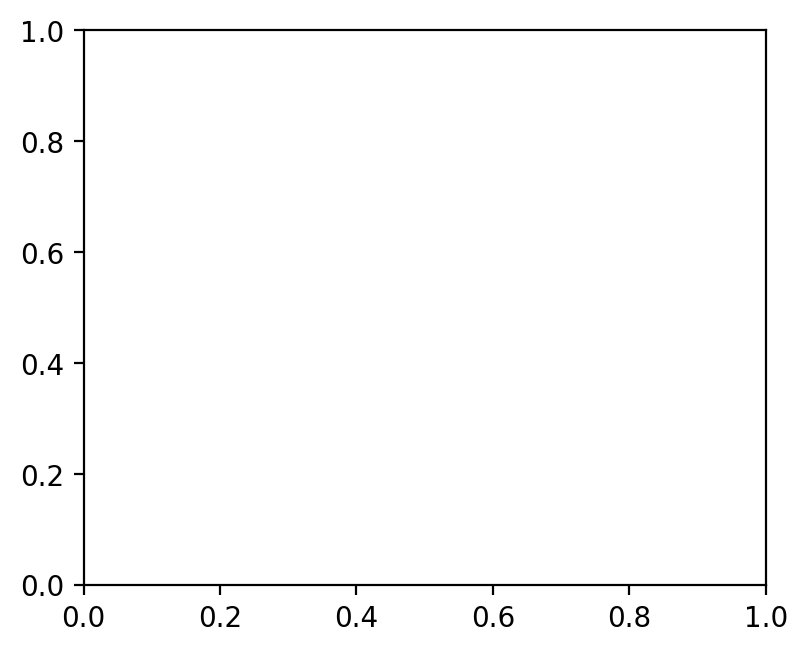

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4.4, 3.6))
pc = ax.pcolormesh(R_F, meanFN, MCS, shading='nearest', cmap='viridis')
cs = ax.contour(R_F, meanFN, MCS, levels=[2, 3, 5, 8, 12, 20], colors='white', linewidths=0.6)
ax.clabel(cs, fontsize=6, fmt='%g')
ax.plot(0.4, base['fn'].mean(), 'o', ms=9, color='#2E86AB', mec='white', label='pre+rec')
ax.plot(0.0, ssh.build_forcings(['post'])['post']['fn'].mean(), 'o', ms=9,
        color='#E07A5F', mec='white', label='post')
ax.set_xlabel('fish rate  r$_F$'); ax.set_ylabel('mean F$_N$  (mmol N m$^{-2}$ d$^{-1}$)')
fig.colorbar(pc, label='mean cell size (µm)')
ax.legend(fontsize=7, frameon=False); fig.tight_layout(); plt.show()

# Let's diagnose what is causing this:

In [7]:
clim, r = ssh.run_one(spec, {**base, 'fn': base['fn']*1.7}, fish_rate=0.0,
                      years=20, spinup=2, mP=0.0015, m_Z=0.1,
                      grazing=GRZ, iv_overrides=IVO,
                      solver_kwargs=SK, return_traj=True)
# look at the last ~365 d before NaN
t = r['t']; ok = ~np.isnan(r['sumP']); t_end = t[ok][-1]
mask = (t >= t_end - 365) & ok
print('crash time (d):', t_end, '  N_min:', np.nanmin(r['N'][mask]),
      '  Z>200 peak:', np.nanmax(r['Z200'][mask]),
      '  minP floor:', np.nanmin(r['minP'][mask]),
      '  sumP peak:', np.nanmax(r['sumP'][mask]))

crash time (d): 7299.999999999999   N_min: 4.748295227268713   Z>200 peak: 0.24331038294059887   minP floor: 0.0   sumP peak: 0.8139728458175906


In [ ]:
import warnings, time, numpy as np, seasonal_scan_harness as ssh
warnings.filterwarnings('ignore', message='Instability event')

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}
TRIP = dict(construct=spec, forcing={**base, 'fn': base['fn'] * 0.617},
            fish_rate=0.6, years=20, spinup=2,
            mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO, return_traj=True)

def _try(label, sk):
    t0 = time.perf_counter()
    clim, r = ssh.run_one(**TRIP, solver_kwargs=sk)
    dt = time.perf_counter() - t0
    t = r['t']; sp = r['sumP']; ok = ~np.isnan(sp)
    last_ok = t[ok][-1] if ok.any() else np.nan
    print(f"{label:20s} | wall {dt:5.1f}s | last finite t={last_ok:7.1f} d "
          f"({last_ok/365:5.2f} yr) | has_nan={clim['has_nan']} | "
          f"minP={np.nanmin(r['minP']):+.2e}  minZ={np.nanmin(r['minZ']):+.2e} | "
          f"sumP last={sp[ok][-1] if ok.any() else np.nan:.3f}")
    return clim, r

c_rk, r_rk = _try('RK45 (default)',  {'instability_neg_threshold': -1e-3})
c_bdf, r_bdf = _try('BDF, rtol=1e-4', {'method': 'BDF', 'rtol': 1e-4, 'atol': 1e-6,
                                        'instability_neg_threshold': -1e-3})
c_bdf2, r_bdf2 = _try('BDF, tight',   {'method': 'BDF', 'rtol': 1e-6, 'atol': 1e-9,
                                        'instability_neg_threshold': -1e-3})

In [9]:
import warnings, numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks

# Capture the trip warning text instead of silencing it
TRIPS = []
def _trip_capturing_warner(message, category, filename, lineno, file=None, line=None):
    msg = str(message)
    if 'Instability event' in msg:
        TRIPS.append(msg)
warnings.showwarning = _trip_capturing_warner

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}
SK = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -3e-2}

FN_SCALE = np.linspace(0.4, 1.7, 7)
R_F      = np.linspace(0.0, 0.6, 7)
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan); CONV = MCS.copy(); TRIPLOC = {}
trip_log = []   # (fs, rf, trip_msg_or_None)
def on_result(item, done, n):
    k = item['index']
    i, j = divmod(k, len(R_F))
    fs, rf = combos[k]
    if item['ok']:
        m = item['result']
        MCS[i, j]  = m.get('mcs_med', np.nan)
        CONV[i, j] = m.get('mcs_conv', np.nan)
        if m.get('has_nan'):
            # `TRIPS` is appended to in arrival order, not submission order, so we tag this
            # cell as tripped without claiming a specific message-text match
            TRIPLOC[(i, j)] = (float(fs), float(rf), float(m.get('nan_frac', np.nan)))
            trip_log.append((float(fs), float(rf), m.get('nan_frac', np.nan)))

run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None, on_result=on_result,
                   tally_flags=['has_nan'], label='fig5')

# Diagnostic summary
trip_cells = sorted(TRIPLOC.items(), key=lambda kv: (kv[1][0], kv[1][1]))
print(f"\nTrips: {len(trip_cells)} / {MCS.size}")
for (i, j), (fs, rf, frac) in trip_cells:
    print(f"  cell (i={i}, j={j}) | F_N×{fs:.3f} (mean {base['fn'].mean()*fs:.2f}) "
          f"| r_F={rf:.2f} | nan_frac={frac:.2f}")
print(f"\nRaw trip messages captured ({len(TRIPS)}):")
for m in TRIPS[:10]:
    # extract the "P[15] = -0.0527" / "Z[19] = ..." style locator
    import re
    loc = re.search(r'on\s+([PZ])\[(\d+)\]\s*=\s*([\-\d\.e]+)', m)
    t   = re.search(r't=([\d\.e\+\-]+)', m)
    print(f"  t={t.group(1) if t else '?':>10s}  class={loc.group(1)+'['+loc.group(2)+']' if loc else '?':>8s}  value={loc.group(3) if loc else '?'}")

--- run_parallel_tasks: 49 tasks, 7 workers (fig5) ---
   1/49 fig5 | err=0 has_nan=0 | 0.3m ETA 13.0m
   2/49 fig5 | err=0 has_nan=0 | 0.3m ETA 6.5m
   3/49 fig5 | err=0 has_nan=0 | 0.3m ETA 4.3m
   4/49 fig5 | err=0 has_nan=0 | 0.3m ETA 3.2m
   5/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.5m
   6/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.0m
   7/49 fig5 | err=0 has_nan=0 | 0.3m ETA 1.7m
   8/49 fig5 | err=0 has_nan=0 | 0.4m ETA 2.3m
   9/49 fig5 | err=0 has_nan=0 | 0.5m ETA 2.2m
  10/49 fig5 | err=0 has_nan=0 | 0.5m ETA 2.1m
  11/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.9m
  12/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.7m
  13/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.5m
  14/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.4m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1639 on P[15] = -0.0544. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  15/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.3m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2786 on P[15] = -0.0349. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  16/49 fig5 | err=0 has_nan=2 | 0.6m ETA 1.2m


...

  44/49 fig5 | err=0 has_nan=18 | 1.4m ETA 0.2m
  45/49 fig5 | err=0 has_nan=19 | 1.4m ETA 0.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2760 on Z[19] = -0.03. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  46/49 fig5 | err=0 has_nan=20 | 1.4m ETA 0.1m
  47/49 fig5 | err=0 has_nan=20 | 1.5m ETA 0.1m
  48/49 fig5 | err=0 has_nan=20 | 1.5m ETA 0.0m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=7100 on P[18] = -0.05. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  49/49 fig5 | err=0 has_nan=21 | 1.5m ETA 0.0m
--- fig5 done: 49/49 ok, 0 errored, has_nan=21 | 1.5m ---

Trips: 21 / 49
  cell (i=2, j=3) | F_N×0.833 (mean 2.56) | r_F=0.30 | nan_frac=1.00
  cell (i=2, j=5) | F_N×0.833 (mean 2.56) | r_F=0.50 | nan_frac=1.00
  cell (i=2, j=6) | F_N×0.833 (mean 2.56) | r_F=0.60 | nan_frac=0.84
  cell (i=3, j=4) | F_N×1.050 (mean 3.23) | r_F=0.40 | nan_frac=1.00
  cell (i=3, j=6) | F_N×1.050 (mean 3.23) | r_F=0.60 | nan_frac=0.88
  cell (i=4, j=1) | F_N×1.267 (mean 3.89) | r_F=0.10 | nan_frac=1.00
  cell (i=4, j=2) | F_N×1.267 (mean 3.89) | r_F=0.20 | nan_frac=0.49
  cell (i=4, j=3) | F_N×1.267 (mean 3.89) | r_F=0.30 | nan_frac=0.14
  cell (i=4, j=4) | F_N×1.267 (mean 3.89) | r_F=0.40 | nan_frac=0.88
  cell (i=4, j=5) | F_N×1.267 (mean 3.89) | r_F=0.50 | nan_frac=1.00
  cell (i=5, j=1) | F_N×1.483 (mean 4.56) | r_F=0.10 | nan_frac=0.95
  cell (i=5, j=2) | F_N×1.483 (mean 4.56) | r_F=0.20 | nan_frac=1.00
  cell (i=5, j=3) | F_N×1.483 (mean 4.56) | r_F=0.

In [10]:
SK_NO_FLOOR = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': float('-inf')}

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan)
CONV = MCS.copy(); MINP = MCS.copy(); MINZ = MCS.copy(); CVSP = MCS.copy(); HASN = MCS.copy()

def on_result_diag(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if item['ok']:
        m = item['result']
        MCS[i,j]  = m.get('mcs_med', np.nan)
        CONV[i,j] = m.get('mcs_conv', np.nan)
        MINP[i,j] = m.get('minP', np.nan)
        MINZ[i,j] = m.get('minZ', np.nan)
        CVSP[i,j] = m.get('cv_sumP', np.nan)
        HASN[i,j] = float(bool(m.get('has_nan', False)))

tasks_nf = [(dict(**{**t[0], 'solver_kwargs': SK_NO_FLOOR}),) for t in tasks]
run_parallel_tasks(ssh._seasonal_worker, tasks_nf, processes=None,
                   on_result=on_result_diag, tally_flags=['has_nan'], label='fig5_nofloor')

# Categorise
import pandas as pd
prev_trips = set(TRIPLOC.keys())               # cells that tripped under -3e-2 floor
rows = []
for (i, j) in prev_trips:
    mp, mz, cv, cn, nan = MINP[i,j], MINZ[i,j], CVSP[i,j], CONV[i,j], HASN[i,j]
    fs, rf = combos[i*len(R_F)+j]
    # category rules
    if nan or not np.isfinite(MCS[i,j]):
        cat = '2: blew up'
    elif min(mp, mz) > -3e-2:
        cat = '1: clean (negs within current floor)'
    elif min(mp, mz) > -0.15 and abs(cn - 1) < 0.3:
        cat = '1: small scar, climatology sane'
    elif abs(cn - 1) >= 0.3 or cv > 1.0:
        cat = '3: nonconvergent / wild'
    else:
        cat = '?: needs eyeball'
    rows.append(dict(i=i, j=j, FN=fs*base['fn'].mean(), rF=rf,
                     mcs=MCS[i,j], minP=mp, minZ=mz, cv_sumP=cv, conv=cn, cat=cat))
df = pd.DataFrame(rows).sort_values(['FN', 'rF'])
print(df.to_string(index=False))
print('\nCategory counts:')
print(df['cat'].value_counts().to_string())

--- run_parallel_tasks: 49 tasks, 7 workers (fig5_nofloor) ---
   1/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 13.5m
   2/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 7.2m
   3/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 4.9m
   4/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 3.6m
   5/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.9m
   6/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.3m
   7/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.0m
   8/49 fig5_nofloor | err=0 has_nan=0 | 0.5m ETA 2.8m
   9/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.5m
  10/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.3m
  11/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.1m
  12/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.9m
  13/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.7m
  14/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.5m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1761 on P[18] = 1.03e+50 (plus 1 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  15/49 fig5_nofloor | err=0 has_nan=1 | 0.7m ETA 1.5m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3741 on P[19] = 1.67e+50 (plus 3 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  16/49 fig5_nofloor | err=0 has_nan=2 | 0.7m ETA 1.4m
  17/49 fig5_nofloor | err=0 has_nan=2 | 0.8m ETA 1.4m
  18/49 fig5_nofloor | err=0 has_nan=2 | 0.8m ETA 1.4m
  19/49 fig5_nofloor | err=0 has_nan=3 | 0.8m ETA 1.3m
  20/49 fig5_nofloor | err=0 has_nan=3 | 0.8m ETA 1.2m
  21/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  22/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  23/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  24/49 fig5_nofloor | err=0 has_nan=3 | 1.0m ETA 1.1m
  25/49 fig5_nofloor | err=0 has_nan=3 | 1.1m ETA 1.0m


...

  47/49 fig5_nofloor | err=0 has_nan=19 | 3.7m ETA 0.2m


/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/scipy/integrate/_ivp/base.py:24: UserWarning: solve_ivp has used 640000 RHS evaluations after 63.5% of the time span — at this rate the run will use ~1.0e+06 total RHS calls. The integration may take a long time. Consider Ctrl-C and restarting with solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems). If you are already on stiff_ivp and nfev is still projecting high, the model is not classically stiff — try solver='solve_ivp' (RK45 default) instead. (This warning fires once per process.)
  return np.asarray(fun(t, y), dtype=dtype)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 1165376 RHS evaluations for 2521 output points (462/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian

  48/49 fig5_nofloor | err=0 has_nan=20 | 9.7m ETA 0.2m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 1362218 RHS evaluations for 9274 output points (147/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may not for oscillatory predator-prey models), or loosening tolerances via solver_kwargs={'atol': 1e-6, 'rtol': 1e-4}. (This warning fires once per process.)
  self.solver.solve(self.model, time_step)


  49/49 fig5_nofloor | err=0 has_nan=21 | 11.2m ETA 0.0m
--- fig5_nofloor done: 49/49 ok, 0 errored, has_nan=21 | 11.2m ---
 i  j       FN  rF      mcs      minP          minZ  cv_sumP     conv                                  cat
 2  3 2.561264 0.3      NaN       NaN           NaN      NaN      NaN                           2: blew up
 2  5 2.561264 0.5      NaN       NaN           NaN      NaN      NaN                           2: blew up
 2  6 2.561264 0.6      NaN       NaN           NaN      NaN      NaN                           2: blew up
 3  4 3.227192 0.4 3.417513 -0.000002 -9.968582e-13 1.059457 1.013633 1: clean (negs within current floor)
 3  6 3.227192 0.6      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  1 3.893121 0.1      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  2 3.893121 0.2      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  3 3.893121 0.3  

In [11]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, xso
import parscan_utils_extended as pue
import seasonal_scan_harness as ssh
from baseline_r0_setups import (
    model_baseline, make_baseline_input_vars, SLIM_OUTPUT_VARS,
    IVP_SOLVER_KWARGS, phyto_esd, zoo_esd,
)

# --- construct: same overrides as the seasonal Fig 4 / Fig 5 work ---
spec = ssh.allometry('maranon_ward')          # Marañón μ + Ward K_s
mu_max_arr, ks_arr = spec['mu_max'], spec['halfsat']

# --- SS operating point: pre+rec era markers, decoupled forcing ---
FN0, RF0, DE0, T0 = 2.94, 0.4, 50.0, 20.0     # T0 = T_REF -> Q10 = 1 (no T effect)

iv = make_baseline_input_vars(
    fish_rate=RF0, FN=FN0, de=DE0, T=T0,
    mu_max=mu_max_arr, halfsat=ks_arr,
    mP=0.0015, m_Z=0.1,
)
iv['Grazing']['KsZ']       = 0.23
iv['Grazing']['sigma_log'] = 0.20
iv['GrazingRouter']['gge'] = 0.31

T_END = 5000.0
time_ax = np.arange(0.0, T_END, 1.0)
setup = xso.setup(solver='solve_ivp', model=model_baseline, time=time_ax,
                  input_vars=iv, output_vars=SLIM_OUTPUT_VARS,
                  solver_kwargs=IVP_SOLVER_KWARGS)
import time as _t
t0 = _t.perf_counter()
out = pue.run_single_point(model_baseline, setup, {})
print(f"wall {_t.perf_counter()-t0:.1f} s\n")

# --- diagnostics over the last 1000 d ---
P = out['Phytoplankton__biomass'].transpose('phyto', 'time').values
Z = out['Zooplankton__biomass'].transpose('zoo',   'time').values
N = out['Nutrient__value'].values
t = out['time'].values
ok_mask = ~np.isnan(P[0])
t_last = t[ok_mask][-1]
tail = (t >  t_last - 1000) & ok_mask
last100 = (t >  t_last - 100)  & ok_mask
prev100 = (t >  t_last - 200) & (t <= t_last - 100) & ok_mask

W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
bins = W @ P; sb = bins.sum(0)
fr = np.divide(bins, sb, out=np.full_like(bins, np.nan), where=sb > 0)
mcs   = 10 ** (np.log10(GEOM) @ fr)
sumP  = P.sum(0); sumZ = Z.sum(0)
Z200  = Z[zoo_esd > 200].sum(0); Z500 = Z[zoo_esd > 500].sum(0)

def stat(x): return np.nanmean(x[tail]), np.nanstd(x[tail])
m_mcs, s_mcs = stat(mcs); m_sP, s_sP = stat(sumP); m_sZ, s_sZ = stat(sumZ)
m_N, s_N = stat(N); m_Z200, _ = stat(Z200); m_Z500, _ = stat(Z500)
m_pico, m_nano, m_micro = [np.nanmean(fr[k, tail]) for k in (0, 1, 2)]
conv = np.nanmean(mcs[last100]) / max(np.nanmean(mcs[prev100]), 1e-12)
minP_tail = float(np.nanmin(P[:, tail])); minZ_tail = float(np.nanmin(Z[:, tail]))

print(f"Run reached t = {t_last:.0f} d (target {T_END:.0f}). "
      f"has_nan = {bool(np.isnan(P).any())}\n")
print(f"Tail mean ± SD over last 1000 d:")
print(f"  mcs        = {m_mcs:6.3f} ± {s_mcs:.3f}  µm")
print(f"  Pico/Nano/Micro fractions = {m_pico:.2f} / {m_nano:.2f} / {m_micro:.2f}")
print(f"  ΣP         = {m_sP:6.3f} ± {s_sP:.3f}  mmol N m⁻³")
print(f"  ΣZ         = {m_sZ:6.3f} ± {s_sZ:.3f}  mmol N m⁻³")
print(f"  Z>200      = {m_Z200:.4f}     Z>500 = {m_Z500:.4e}  mmol N m⁻³")
print(f"  N          = {m_N:6.3f} ± {s_N:.3f}  mmol N m⁻³")
print(f"\nPhysical-ness / convergence:")
print(f"  minP over tail = {minP_tail:+.2e}  (want ≥ 0)")
print(f"  minZ over tail = {minZ_tail:+.2e}  (want ≥ 0)")
print(f"  mcs last100 / prev100 = {conv:.4f}  (want ~1.000)")
print(f"\nObs targets at the pre+rec operating point (for comparison):")
print(f"  obs MCS (pre+rec)  ≈ 7.66 µm   |  Micro ≈ 0.42  |  Z>200 ≈ 0.057  mmol N m⁻³")

wall 2.5 s

Run reached t = 4877 d (target 5000). has_nan = True

Tail mean ± SD over last 1000 d:
  mcs        =  4.285 ± 0.167  µm
  Pico/Nano/Micro fractions = 0.47 / 0.24 / 0.30
  ΣP         =  0.650 ± 0.006  mmol N m⁻³
  ΣZ         =  0.232 ± 0.000  mmol N m⁻³
  Z>200      = 0.0255     Z>500 = 1.8050e-04  mmol N m⁻³
  N          =  0.748 ± 0.004  mmol N m⁻³

Physical-ness / convergence:
  minP over tail = +0.00e+00  (want ≥ 0)
  minZ over tail = -4.05e-05  (want ≥ 0)
  mcs last100 / prev100 = 0.9769  (want ~1.000)

Obs targets at the pre+rec operating point (for comparison):
  obs MCS (pre+rec)  ≈ 7.66 µm   |  Micro ≈ 0.42  |  Z>200 ≈ 0.057  mmol N m⁻³


In [4]:
%config InlineBackend.figure_format = 'retina'
import time as _t
import numpy as np
from xso.parscans import run_xso_parscan
import seasonal_scan_harness as ssh
from baseline_r0_setups import phyto_esd

# --- axes ---
FN_VALUES = np.linspace(0.5, 6.0, 14)            # mmol N m-2 d-1
RF_VALUES = np.linspace(0.0, 0.6, 7)
DE0, T0   = 50.0, 20.0                            # decoupled forcing (T = T_REF)

# --- construct: Marañón+Ward growth + construct-D scalars ---
spec = ssh.allometry('maranon_ward')
fixed = {
    # decoupled forcing
    'Inflow__de':             DE0,
    'Temperature__value':     T0,
    # growth (Marañón μ + Ward K_s)
    'Growth__mu_max':         spec['mu_max'],
    'Growth__halfsat':        spec['halfsat'],
    # construct-D scalars (same as Fig 4 model + seasonal scan)
    'PhytoMortality__rate':   0.0015,
    'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ':           0.23,
    'Grazing__sigma_log':     0.20,
    'GrazingRouter__gge':     0.31,
}

t0 = _t.perf_counter()
scan = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim_tight',
    param_name='Inflow__FN',         param_values=FN_VALUES,
    param_name2='FishGrazing__rate', param_values2=RF_VALUES,
    fixed_overrides=fixed,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall: {(_t.perf_counter()-t0)/60:.1f} min\n")

# --- summary: list scan variables, check shape, sanity-print MCS surface ---
print("scan variables:", list(scan.data_vars))
print("scan dims     :", dict(scan.sizes))

# Try common reduction names — `avg_tail_stats` emits scalars per cell;
# adjust the keys below if the actual variable names differ.
def _take(name):
    return scan[name].values if name in scan.data_vars else None

print("\nQuick MCS surface preview (rows = F_N ↑, cols = r_F →):")
mcs = None
for k in ('mcs', 'mcs_mean', 'MCS', 'mcs_tail'):
    v = _take(k)
    if v is not None and v.shape == (len(FN_VALUES), len(RF_VALUES)):
        mcs = v; print(f"  using '{k}'"); break

if mcs is not None:
    print('       ' + '  '.join(f'r_F={rf:.2f}' for rf in RF_VALUES))
    for i, FN in enumerate(FN_VALUES):
        row = '  '.join(f'{mcs[i,j]:7.2f}' if np.isfinite(mcs[i,j]) else '    nan'
                        for j in range(len(RF_VALUES)))
        print(f'{FN:5.2f}   {row}')
    print(f"\nMCS  min={np.nanmin(mcs):.2f}  max={np.nanmax(mcs):.2f}  µm")
    print(f"finite cells: {int(np.sum(np.isfinite(mcs)))}/{mcs.size}")
else:
    print("  → no mcs-like variable found in scan output; print data_vars + ",
          "head/tail of one variable so we can resolve names.")
    for k in list(scan.data_vars)[:6]:
        print(f"  {k}: shape={scan[k].shape}  dims={scan[k].dims}")

# Flag non-converged cells if cv_sumP / tail_has_nan / similar are present
for diag in ('cv_sumP', 'cv_sumZ', 'cv_N', 'tail_has_nan'):
    if diag in scan.data_vars:
        v = scan[diag].values
        if v.dtype == bool or v.dtype == object:
            print(f"{diag}: True in {int(np.sum(v == True))}/{v.size} cells")
        else:
            print(f"{diag}: min={np.nanmin(v):.3g}  max={np.nanmax(v):.3g}  "
                  f"(>0.10 in {int(np.nansum(v > 0.10))} cells)")

PROGRESS: Completed 14/14 outer points. (Inflow__FN = 6.0).

2D Scan complete. Total Time taken: 277.95486 seconds.

wall: 4.6 min

scan variables: ['DetritusSink__sinking_value', 'Detritus__value', 'Growth__uptake_value', 'Nutrient__value', 'Phytoplankton__biomass', 'Time__time_input', 'Zooplankton__biomass', 'Core__solver_kwargs', 'Core__solver_type', 'DetritusRemin__detritus', 'DetritusRemin__k_remin', 'DetritusRemin__nutrient', 'DetritusSink__de', 'DetritusSink__detritus', 'DetritusSink__w_sink', 'Detritus__value_init', 'Detritus__value_label', 'FishGrazing__kernel_P', 'FishGrazing__kernel_Z', 'FishGrazing__phyto', 'FishGrazing__zoo', 'GrazingRouter__assimilated_consumer', 'GrazingRouter__egested_detritus', 'GrazingRouter__excreted_nutrient', 'GrazingRouter__frac_D', 'GrazingRouter__frac_export', 'GrazingRouter__grazed_phyto', 'GrazingRouter__grazed_zoo', 'Grazing__Imax', 'Grazing__consumer', 'Grazing__phyto_esd', 'Grazing__q10', 'Grazing__resource', 'Grazing__t_ref', 'Grazing__tem

Derived surfaces  (nFN x nRF):
  MCS    min=2.22  max=6.67  µm
  ΣP     min=0.31  max=0.99  mmol N m⁻³
  ΣZ     min=0.06  max=0.46  mmol N m⁻³
  Micro  min=0.03  max=0.41
  Z>200  min=0.0000  max=0.2070  mmol N m⁻³
  Z>500  min=0.0000e+00  max=8.9003e-02  mmol N m⁻³
  N      min=0.06    max=8.59    mmol N m⁻³


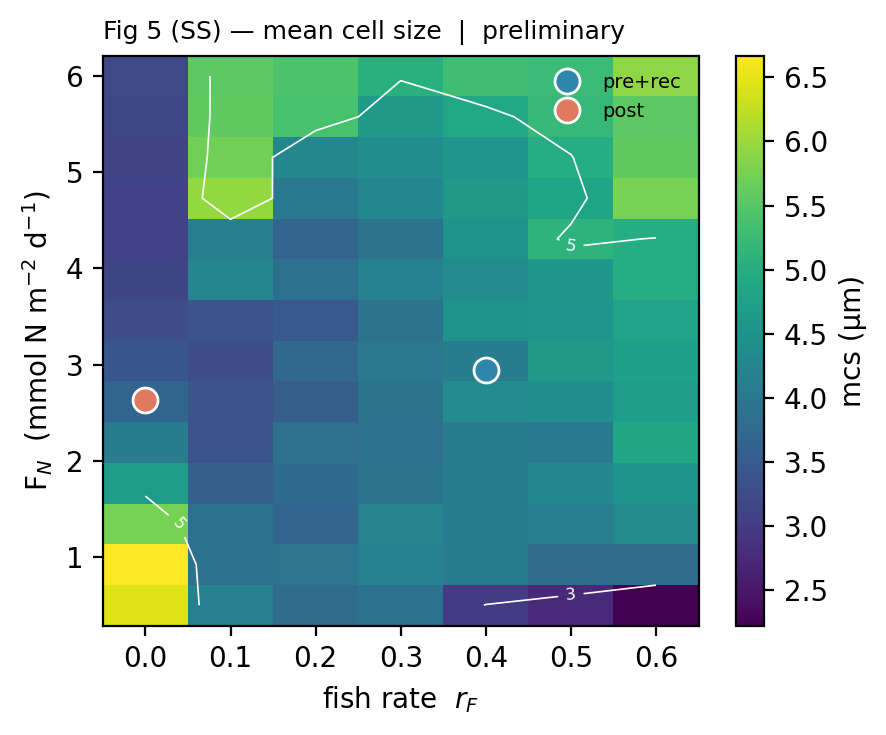


Monotonicity check:
  dMCS/dF_N > 0 in 54/91 edges (if mostly true → MCS rises with F_N)
  dMCS/dr_F > 0 in 58/84 edges (if mostly true → fish increases MCS)

Operating points (nearest grid):
  pre+rec ≈ (3.04, 0.40): MCS=4.05 µm  Micro=0.28  Z>200=0.025
  post     ≈ (2.62, 0.00): MCS=3.66 µm  Micro=0.26  Z>200=0.055
  pre/post MCS ratio: 1.11  (obs ≈ 7.66/3.28 = 2.33)


In [5]:
import numpy as np, matplotlib.pyplot as plt
import parscan_utils_extended as pue
from baseline_r0_setups import phyto_esd, zoo_esd

# --- derive MCS and the other surfaces from tail-averaged state ---
# dims in scan are (FishGrazing__rate, Inflow__FN, time=1, [phyto|zoo])
P = scan['Phytoplankton__biomass'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate', 'phyto').values
Z = scan['Zooplankton__biomass'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate', 'zoo').values
N = scan['Nutrient__value'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate').values
nFN, nRF = P.shape[:2]

W    = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)

bins = np.einsum('kp,ijp->ijk', W, P)               # (nFN, nRF, 3 Sieburth bins)
sb   = bins.sum(-1)                                  # ΣP-binned per cell
fr   = np.where(sb[..., None] > 0, bins / sb[..., None], np.nan)
MCS  = 10 ** (fr @ np.log10(GEOM))                  # (nFN, nRF)
PICO, NANO, MICRO = fr[..., 0], fr[..., 1], fr[..., 2]
SUMP = P.sum(-1)
SUMZ = Z.sum(-1)
Z200 = Z[..., zoo_esd > 200].sum(-1)
Z500 = Z[..., zoo_esd > 500].sum(-1)

print("Derived surfaces  (nFN x nRF):")
print(f"  MCS    min={np.nanmin(MCS):.2f}  max={np.nanmax(MCS):.2f}  µm")
print(f"  ΣP     min={np.nanmin(SUMP):.2f}  max={np.nanmax(SUMP):.2f}  mmol N m⁻³")
print(f"  ΣZ     min={np.nanmin(SUMZ):.2f}  max={np.nanmax(SUMZ):.2f}  mmol N m⁻³")
print(f"  Micro  min={np.nanmin(MICRO):.2f}  max={np.nanmax(MICRO):.2f}")
print(f"  Z>200  min={np.nanmin(Z200):.4f}  max={np.nanmax(Z200):.4f}  mmol N m⁻³")
print(f"  Z>500  min={np.nanmin(Z500):.4e}  max={np.nanmax(Z500):.4e}  mmol N m⁻³")
print(f"  N      min={np.nanmin(N):.2f}    max={np.nanmax(N):.2f}    mmol N m⁻³")

# --- quick-look MCS pcolormesh ---
fig, ax = plt.subplots(figsize=(4.6, 3.8))
pc = ax.pcolormesh(RF_VALUES, FN_VALUES, MCS, shading='nearest', cmap='viridis')
cs = ax.contour(RF_VALUES, FN_VALUES, MCS, levels=[2, 3, 5, 8, 12, 20],
                colors='white', linewidths=0.6)
ax.clabel(cs, fontsize=6, fmt='%g')
ax.plot(0.4, 2.94, 'o', ms=9, color='#2E86AB', mec='white', label='pre+rec')
ax.plot(0.0, 2.63, 'o', ms=9, color='#E07A5F', mec='white', label='post')
ax.set_xlabel('fish rate  $r_F$')
ax.set_ylabel(r'F$_N$  (mmol N m$^{-2}$ d$^{-1}$)')
ax.set_title('Fig 5 (SS) — mean cell size  |  preliminary', fontsize=9, loc='left')
fig.colorbar(pc, label='mcs (µm)')
ax.legend(fontsize=7, frameon=False, loc='upper right')
fig.tight_layout(); plt.show()

# --- sanity-check: monotonic in F_N? in r_F? cross-term curvature? ---
def _slope(arr, axis):
    return np.diff(arr, axis=axis)
dFN = _slope(MCS, axis=0)        # MCS change as F_N rises (along rows)
drF = _slope(MCS, axis=1)        # MCS change as r_F rises (along cols)
print(f"\nMonotonicity check:")
print(f"  dMCS/dF_N > 0 in {int(np.sum(dFN > 0))}/{dFN.size} edges "
      f"(if mostly true → MCS rises with F_N)")
print(f"  dMCS/dr_F > 0 in {int(np.sum(drF > 0))}/{drF.size} edges "
      f"(if mostly true → fish increases MCS)")
print(f"\nOperating points (nearest grid):")
i_pre, j_pre = int(np.argmin(np.abs(FN_VALUES - 2.94))), int(np.argmin(np.abs(RF_VALUES - 0.4)))
i_pos, j_pos = int(np.argmin(np.abs(FN_VALUES - 2.63))), int(np.argmin(np.abs(RF_VALUES - 0.0)))
print(f"  pre+rec ≈ ({FN_VALUES[i_pre]:.2f}, {RF_VALUES[j_pre]:.2f}): "
      f"MCS={MCS[i_pre,j_pre]:.2f} µm  Micro={MICRO[i_pre,j_pre]:.2f}  "
      f"Z>200={Z200[i_pre,j_pre]:.3f}")
print(f"  post     ≈ ({FN_VALUES[i_pos]:.2f}, {RF_VALUES[j_pos]:.2f}): "
      f"MCS={MCS[i_pos,j_pos]:.2f} µm  Micro={MICRO[i_pos,j_pos]:.2f}  "
      f"Z>200={Z200[i_pos,j_pos]:.3f}")
print(f"  pre/post MCS ratio: {MCS[i_pre,j_pre]/MCS[i_pos,j_pos]:.2f}  "
      f"(obs ≈ 7.66/3.28 = 2.33)")

In [6]:
import time as _t, numpy as np
from xso.parscans import run_xso_parscan

t0 = _t.perf_counter()
scan_loose = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',          # <-- default IVP_SOLVER_KWARGS
    param_name='Inflow__FN',         param_values=FN_VALUES,
    param_name2='FishGrazing__rate', param_values2=RF_VALUES,
    fixed_overrides=fixed,                            # reuse the same dict
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall (loose): {(_t.perf_counter()-t0)/60:.1f} min   "
      f"(tight was 4.6 min)\n")

# --- side-by-side: which cells differ? ---
P_loose = scan_loose['Phytoplankton__biomass'].squeeze('time').transpose(
    'Inflow__FN', 'FishGrazing__rate', 'phyto').values
nan_loose  = scan_loose['tail_has_nan'].transpose('Inflow__FN', 'FishGrazing__rate').values
nan_tight  = scan['tail_has_nan'].transpose('Inflow__FN', 'FishGrazing__rate').values
cv_loose   = scan_loose['cv_sumP'].transpose('Inflow__FN', 'FishGrazing__rate').values
cv_tight   = scan['cv_sumP'].transpose('Inflow__FN', 'FishGrazing__rate').values

print("Trip count (tail_has_nan = True):")
print(f"  loose: {int(np.sum(nan_loose != 0))} / {nan_loose.size}")
print(f"  tight: {int(np.sum(nan_tight != 0))} / {nan_tight.size}")
print(f"\ncv_sumP (realised stability):")
print(f"  loose: max={np.nanmax(cv_loose):.4f}  >0.10 in {int(np.sum(cv_loose > 0.10))} cells")
print(f"  tight: max={np.nanmax(cv_tight):.4f}  >0.10 in {int(np.sum(cv_tight > 0.10))} cells")

# Compute MCS on both for direct comparison
W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
def _mcs(P):
    b = np.einsum('kp,ijp->ijk', W, P); s = b.sum(-1)
    f = np.where(s[..., None] > 0, b / s[..., None], np.nan)
    return 10 ** (f @ np.log10(GEOM))

MCS_loose = _mcs(P_loose)
MCS_tight = _mcs(P)        # P from the previous (tight) scan, still in scope
diff = MCS_loose - MCS_tight
print(f"\nMCS_loose vs MCS_tight:")
print(f"  |Δ| max  = {np.nanmax(np.abs(diff)):.4f} µm")
print(f"  |Δ| mean = {np.nanmean(np.abs(diff)):.4f} µm")
print(f"  cells with |Δ| > 0.05 µm: {int(np.nansum(np.abs(diff) > 0.05))} / {diff.size}")
print(f"\nTrip cells in loose (i, j, F_N, r_F):")
trips_ij = np.argwhere(nan_loose != 0)
for i, j in trips_ij:
    print(f"  ({i:2d}, {j}) | F_N={FN_VALUES[i]:.2f}  r_F={RF_VALUES[j]:.2f}")

PROGRESS: Completed 14/14 outer points. (Inflow__FN = 6.0).

2D Scan complete. Total Time taken: 57.92632 seconds.

wall (loose): 1.0 min   (tight was 4.6 min)

Trip count (tail_has_nan = True):
  loose: 14 / 98
  tight: 0 / 98

cv_sumP (realised stability):
  loose: max=0.0215  >0.10 in 0 cells
  tight: max=0.0216  >0.10 in 0 cells

MCS_loose vs MCS_tight:
  |Δ| max  = 0.2284 µm
  |Δ| mean = 0.0074 µm
  cells with |Δ| > 0.05 µm: 2 / 98

Trip cells in loose (i, j, F_N, r_F):
  ( 6, 4) | F_N=3.04  r_F=0.40
  ( 7, 4) | F_N=3.46  r_F=0.40
  ( 7, 5) | F_N=3.46  r_F=0.50
  ( 8, 5) | F_N=3.88  r_F=0.50
  ( 8, 6) | F_N=3.88  r_F=0.60
  ( 9, 5) | F_N=4.31  r_F=0.50
  ( 9, 6) | F_N=4.31  r_F=0.60
  (10, 5) | F_N=4.73  r_F=0.50
  (10, 6) | F_N=4.73  r_F=0.60
  (11, 5) | F_N=5.15  r_F=0.50
  (11, 6) | F_N=5.15  r_F=0.60
  (12, 5) | F_N=5.58  r_F=0.50
  (12, 6) | F_N=5.58  r_F=0.60
  (13, 6) | F_N=6.00  r_F=0.60


In [7]:
import warnings, numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
warnings.filterwarnings('ignore', message='Instability event')
warnings.filterwarnings('ignore', message='solve_ivp')   # nfev projections

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}

# TIGHT solver_kwargs (mirror what worked at SS); default neg floor (-1e-3)
SK_TIGHT = {'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-6,
            'max_step': 1.0, 'instability_neg_threshold': -1e-3}

FN_SCALE = np.linspace(0.4, 1.7, 7)
R_F      = np.linspace(0.0, 0.6, 7)
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK_TIGHT),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan)
CONV = MCS.copy(); MINP = MCS.copy(); MINZ = MCS.copy(); CVSP = MCS.copy()
TRIPLOC_T = {}
def on_result(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if not item['ok']:
        return
    m = item['result']
    MCS[i,j]  = m.get('mcs_med', np.nan)
    CONV[i,j] = m.get('mcs_conv', np.nan)
    MINP[i,j] = m.get('minP', np.nan)
    MINZ[i,j] = m.get('minZ', np.nan)
    CVSP[i,j] = m.get('cv_sumP', np.nan)
    if m.get('has_nan'):
        fs, rf = combos[k]
        TRIPLOC_T[(i, j)] = (float(fs), float(rf), float(m.get('nan_frac', np.nan)))

run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None,
                   on_result=on_result, tally_flags=['has_nan'], label='fig5_seasonal_tight')

# --- diagnostics ---
n_trip = len(TRIPLOC_T)
n_tot  = MCS.size
print(f"\n--- TIGHT seasonal: trips {n_trip}/{n_tot}  (loose baseline was 21/49) ---\n")
if TRIPLOC_T:
    print("Trip cells still firing under tight tols:")
    for (i, j), (fs, rf, frac) in sorted(TRIPLOC_T.items(), key=lambda kv: (kv[1][0], kv[1][1])):
        print(f"  ({i:2d}, {j}) | F_N×{fs:.3f} (mean {base['fn'].mean()*fs:.2f}) "
              f"| r_F={rf:.2f} | nan_frac={frac:.2f}")
else:
    print("All cells completed without NaN-termination.")

# Stability picture of the converged cells
print(f"\ncv_sumP: max={np.nanmax(CVSP):.3f}  >0.10 in {int(np.nansum(CVSP > 0.10))} cells")
print(f"|conv-1|: max={np.nanmax(np.abs(CONV-1)):.3f}  >0.05 in {int(np.nansum(np.abs(CONV-1) > 0.05))} cells")
print(f"minP: min={np.nanmin(MINP):+.2e}  ({int(np.nansum(MINP < -1e-3))} cells < -1e-3)")
print(f"minZ: min={np.nanmin(MINZ):+.2e}  ({int(np.nansum(MINZ < -1e-3))} cells < -1e-3)")

--- run_parallel_tasks: 49 tasks, 7 workers (fig5_seasonal_tight) ---
   1/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.8m ETA 40.4m
   2/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 20.2m
   3/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 13.6m
   4/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 10.0m
   5/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 7.8m
   6/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 6.4m
   7/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 5.3m
   8/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.6m ETA 8.4m
   9/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 7.4m
  10/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 6.5m
  11/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 5.7m
  12/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 5.2m
  13/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 4.7m
  14/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.9m ETA 4.8m
  15/49 fig5_seasonal_tight | err=0 has_nan=0 | 2.4m ETA 5

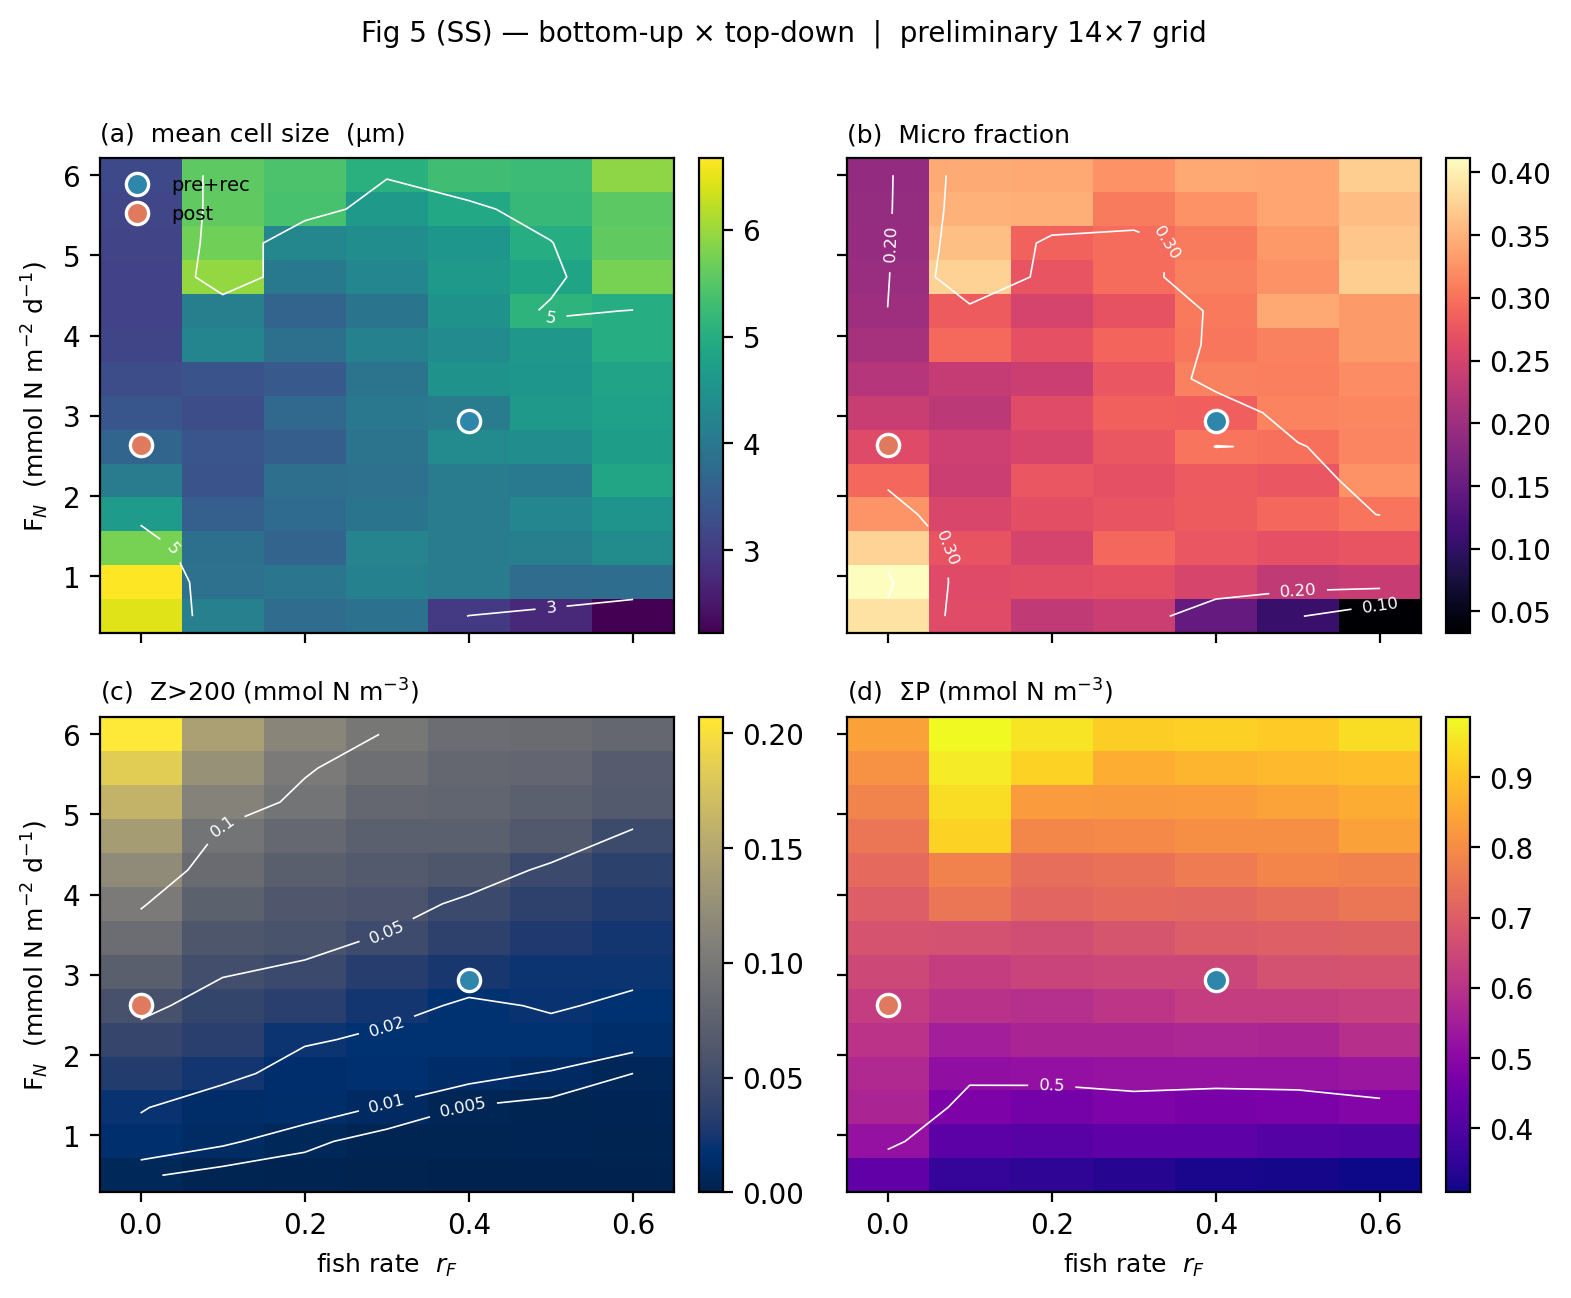

Operating points (nearest grid):
  pre+rec  ≈ (F_N=3.04, r_F=0.40): MCS=4.05 µm  Micro=0.28  Z>200=0.025  ΣP=0.65
  post     ≈ (F_N=2.62, r_F=0.00): MCS=3.66 µm  Micro=0.26  Z>200=0.055  ΣP=0.63

Monotonicity (positive-slope edge count):
  MCS   : dF_N>0 in  54/ 91  |  dr_F>0 in  58/ 84
  Micro : dF_N>0 in  52/ 91  |  dr_F>0 in  53/ 84
  Z>200 : dF_N>0 in  90/ 91  |  dr_F>0 in   9/ 84
  ΣP    : dF_N>0 in  91/ 91  |  dr_F>0 in  48/ 84


In [9]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import parscan_utils_extended as pue
from baseline_r0_setups import phyto_esd, zoo_esd
from matplotlib.colors import LogNorm

# --- derive surfaces from the existing `scan` (tight SS) ---
P = scan['Phytoplankton__biomass'].squeeze('time').transpose('Inflow__FN','FishGrazing__rate','phyto').values
Z = scan['Zooplankton__biomass'].squeeze('time').transpose('Inflow__FN','FishGrazing__rate','zoo').values
N = scan['Nutrient__value'].squeeze('time').transpose('Inflow__FN','FishGrazing__rate').values
W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
bins = np.einsum('kp,ijp->ijk', W, P); sb = bins.sum(-1)
fr = np.where(sb[...,None]>0, bins/sb[...,None], np.nan)
MCS   = 10**(fr @ np.log10(GEOM))
MICRO = fr[...,2]
SUMP  = P.sum(-1); SUMZ = Z.sum(-1)
Z200  = Z[..., zoo_esd>200].sum(-1)

OPS = [('pre+rec', 2.94, 0.4, '#2E86AB'), ('post', 2.63, 0.0, '#E07A5F')]

fig, axes = plt.subplots(2, 2, figsize=(8.0, 6.6), sharex=True, sharey=True)
panels = [
    ('(a)  mean cell size  (µm)',  MCS,  'viridis',  [2,3,5,8,12,20], '%g',  None),
    ('(b)  Micro fraction',        MICRO,'magma',    [0.1,0.2,0.3,0.4,0.5,0.6], '%.2f', None),
    ('(c)  Z>200 (mmol N m$^{-3}$)', Z200,'cividis', [0.005,0.01,0.02,0.05,0.1], '%.3g', None),
    ('(d)  ΣP (mmol N m$^{-3}$)',  SUMP, 'plasma',   [0.2,0.5,1.0,2.0,4.0],  '%.2g', None),
]
for ax, (title, surf, cmap, lvls, fmt, norm) in zip(axes.flat, panels):
    pc = ax.pcolormesh(RF_VALUES, FN_VALUES, surf, shading='nearest', cmap=cmap, norm=norm)
    cs = ax.contour(RF_VALUES, FN_VALUES, surf, levels=lvls, colors='white', linewidths=0.6)
    ax.clabel(cs, fontsize=6, fmt=fmt)
    for lbl, fn, rf, col in OPS:
        ax.plot(rf, fn, 'o', ms=8, color=col, mec='white', mew=1.2, label=lbl)
    ax.set_title(title, fontsize=9, loc='left')
    fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
axes[0,0].legend(fontsize=7, frameon=False, loc='upper left')
for ax in axes[1,:]: ax.set_xlabel('fish rate  $r_F$', fontsize=9)
for ax in axes[:,0]: ax.set_ylabel(r'F$_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=9)
fig.suptitle('Fig 5 (SS) — bottom-up × top-down  |  preliminary 14×7 grid', fontsize=10)
fig.tight_layout(rect=(0,0,1,0.97)); plt.show()

# --- read-off: operating-point numbers + monotonicity ---
print("Operating points (nearest grid):")
for lbl, fn, rf, _ in OPS:
    i, j = int(np.argmin(np.abs(FN_VALUES - fn))), int(np.argmin(np.abs(RF_VALUES - rf)))
    print(f"  {lbl:8s} ≈ (F_N={FN_VALUES[i]:.2f}, r_F={RF_VALUES[j]:.2f}): "
          f"MCS={MCS[i,j]:.2f} µm  Micro={MICRO[i,j]:.2f}  Z>200={Z200[i,j]:.3f}  ΣP={SUMP[i,j]:.2f}")
def _mono(a, ax): return int(np.sum(np.diff(a, axis=ax) > 0))
print(f"\nMonotonicity (positive-slope edge count):")
for name, surf in [('MCS', MCS), ('Micro', MICRO), ('Z>200', Z200), ('ΣP', SUMP)]:
    print(f"  {name:6s}: dF_N>0 in {_mono(surf,0):3d}/{(surf.shape[0]-1)*surf.shape[1]:3d}  |  "
          f"dr_F>0 in {_mono(surf,1):3d}/{surf.shape[0]*(surf.shape[1]-1):3d}")

In [ ]:
import time as _t, numpy as np, os
from xso.parscans import run_xso_parscan
import seasonal_scan_harness as ssh

FN_HI = np.linspace(0.5, 6.0, 50)
RF_HI = np.linspace(0.0, 0.6, 50)
spec  = ssh.allometry('maranon_ward')
fixed_hi = {
    'Inflow__de': 50.0, 'Temperature__value': 20.0,
    'Growth__mu_max': spec['mu_max'], 'Growth__halfsat': spec['halfsat'],
    'PhytoMortality__rate': 0.0015, 'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ': 0.23, 'Grazing__sigma_log': 0.20, 'GrazingRouter__gge': 0.31,
}

t0 = _t.perf_counter()
scan_hi = run_xso_parscan(
    model_file_name='baseline_r0_setups', model_name='model_baseline',
    model_setup_name='setup_baseline_slim_tight',
    param_name='Inflow__FN',         param_values=FN_HI,
    param_name2='FishGrazing__rate', param_values2=RF_HI,
    fixed_overrides=fixed_hi,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall: {(_t.perf_counter()-t0)/60:.1f} min")

# Save to netCDF — figure can be re-rendered from this without re-running
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_ss_scan_28x13_2026-06-24.nc')
# arrays in fixed_overrides are stored as object dtype in xarray; drop those
# from the saved dataset (they're recoverable from the construct spec, and
# netCDF doesn't serialize them cleanly)
to_save = scan_hi.drop_vars([v for v in scan_hi.data_vars
                              if scan_hi[v].dtype == object])
to_save.attrs.update(dict(
    construct='maranon_ward',
    GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
    de=50.0, T=20.0, forcing='SS, decoupled (T=T_REF, de=DE_DEFAULT)',
    solver='setup_baseline_slim_tight (atol=1e-9, rtol=1e-6, max_step=1.0)',
    created='2026-06-24',
))
to_save.to_netcdf(nc_path)
print(f"saved: {nc_path}  ({os.path.getsize(nc_path)/1e6:.1f} MB)")
print(f"  reload with: scan_hi = xarray.open_dataset('{nc_path}')")
print(f"  trips: {int(scan_hi['tail_has_nan'].sum().item())}/{scan_hi['tail_has_nan'].size}")
print(f"  cv_sumP max: {float(scan_hi['cv_sumP'].max().item()):.4f}")

PROGRESS: Completed 7/50 outer points. (Inflow__FN = 0.6122448979591837).


In [11]:
import warnings, numpy as np, time as _t
import seasonal_scan_harness as ssh
warnings.filterwarnings('ignore', message='Instability event')

# pick the cell that was running hardest under RK45-tight
i_hi, j_hi = np.unravel_index(np.nanargmax(CVSP), CVSP.shape)
fs_hi, rf_hi = float(FN_SCALE[i_hi]), float(R_F[j_hi])
mean_fn_hi = base['fn'].mean() * fs_hi
mcs_rk45 = MCS[i_hi, j_hi]; cv_rk45 = CVSP[i_hi, j_hi]; conv_rk45 = CONV[i_hi, j_hi]
print(f"Target cell (max cv_sumP under RK45-tight):")
print(f"  (i, j) = ({i_hi}, {j_hi})  | F_N×{fs_hi:.3f} (mean {mean_fn_hi:.2f})  r_F={rf_hi:.2f}")
print(f"  RK45-tight: mcs_med={mcs_rk45:.3f} µm  cv_sumP={cv_rk45:.3f}  conv={conv_rk45:.4f}\n")

SK_DOP = {'method': 'DOP853', 'atol': 1e-9, 'rtol': 1e-6,
          'max_step': 1.0, 'instability_neg_threshold': -1e-3}
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}

t0 = _t.perf_counter()
clim_dop = ssh.run_one(construct=spec,
                       forcing={**base, 'fn': base['fn'] * fs_hi},
                       fish_rate=rf_hi, years=40, spinup=10,
                       mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                       solver_kwargs=SK_DOP)
wall = _t.perf_counter() - t0
print(f"DOP853 wall: {wall:.1f} s\n")

mcs_dop  = clim_dop.get('mcs_med', np.nan)
cv_dop   = clim_dop.get('cv_sumP', np.nan)
conv_dop = clim_dop.get('mcs_conv', np.nan)
minP_dop = clim_dop.get('minP', np.nan)
print(f"DOP853:    mcs_med={mcs_dop:.3f} µm  cv_sumP={cv_dop:.3f}  conv={conv_dop:.4f}  "
      f"has_nan={clim_dop.get('has_nan')}  minP={minP_dop:+.2e}")
print(f"\nΔ vs RK45-tight:")
print(f"  Δmcs    = {mcs_dop - mcs_rk45:+.4f} µm  ({abs(mcs_dop-mcs_rk45)/max(mcs_rk45,1e-12)*100:.2f} %)")
print(f"  Δcv_sumP = {cv_dop - cv_rk45:+.4f}   ({abs(cv_dop-cv_rk45)/max(cv_rk45,1e-12)*100:.2f} %)")
print(f"  Δconv   = {conv_dop - conv_rk45:+.4f}")

Target cell (max cv_sumP under RK45-tight):
  (i, j) = (6, 2)  | F_N×1.700 (mean 5.22)  r_F=0.20
  RK45-tight: mcs_med=3.704 µm  cv_sumP=1.380  conv=0.8656

DOP853 wall: 67.0 s

DOP853:    mcs_med=nan µm  cv_sumP=nan  conv=nan  has_nan=True  minP=+nan

Δ vs RK45-tight:
  Δmcs    = +nan µm  (nan %)
  Δcv_sumP = +nan   (nan %)
  Δconv   = +nan


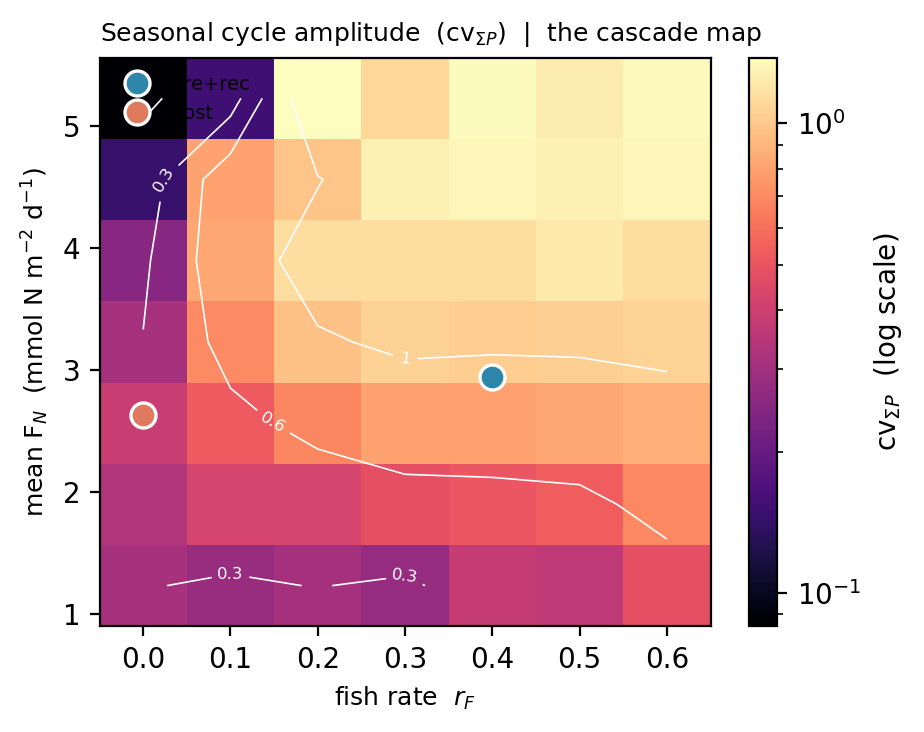

cv_sumP at the era operating points (nearest grid):
  pre+rec  ≈ (F_N=3.23, r_F=0.40): cv_sumP=1.038  mcs_med=4.07 µm
  post     ≈ (F_N=2.56, r_F=0.00): cv_sumP=0.390  mcs_med=5.75 µm

cv_sumP range across the plane: 0.085 – 1.380
highest-cv cell: (F_N=5.22, r_F=0.20)  cv=1.380

Correlation of cv_sumP with mcs_med across the plane:


ValueError: operands could not be broadcast together with shapes (7,7) (14,7) 

In [12]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mean_FN = base['fn'].mean() * FN_SCALE

fig, ax = plt.subplots(figsize=(4.8, 3.8))
pc = ax.pcolormesh(R_F, mean_FN, CVSP, shading='nearest', cmap='magma',
                   norm=LogNorm(vmin=max(np.nanmin(CVSP), 1e-3), vmax=np.nanmax(CVSP)))
cs = ax.contour(R_F, mean_FN, CVSP, levels=[0.05, 0.1, 0.3, 0.6, 1.0],
                colors='white', linewidths=0.6)
ax.clabel(cs, fontsize=6, fmt='%.2g')

# era operating points
ax.plot(0.4, 2.94, 'o', ms=9, color='#2E86AB', mec='white', mew=1.2, label='pre+rec')
ax.plot(0.0, 2.63, 'o', ms=9, color='#E07A5F', mec='white', mew=1.2, label='post')

ax.set_xlabel('fish rate  $r_F$', fontsize=9)
ax.set_ylabel(r'mean F$_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=9)
ax.set_title('Seasonal cycle amplitude  (cv$_{\\Sigma P}$)  |  the cascade map',
             fontsize=9, loc='left')
ax.legend(fontsize=7, frameon=False, loc='upper left')
cb = fig.colorbar(pc, label=r'cv$_{\Sigma P}$  (log scale)')
fig.tight_layout(); plt.show()

# numerical read-off
print("cv_sumP at the era operating points (nearest grid):")
for lbl, fn, rf in [('pre+rec', 2.94, 0.4), ('post', 2.63, 0.0)]:
    i = int(np.argmin(np.abs(mean_FN - fn)))
    j = int(np.argmin(np.abs(R_F - rf)))
    print(f"  {lbl:8s} ≈ (F_N={mean_FN[i]:.2f}, r_F={R_F[j]:.2f}): "
          f"cv_sumP={CVSP[i,j]:.3f}  mcs_med={MCS[i,j]:.2f} µm")
print(f"\ncv_sumP range across the plane: {np.nanmin(CVSP):.3f} – {np.nanmax(CVSP):.3f}")
print(f"highest-cv cell: (F_N={mean_FN[i_hi]:.2f}, r_F={R_F[j_hi]:.2f})  cv={CVSP[i_hi,j_hi]:.3f}")
print(f"\nCorrelation of cv_sumP with mcs_med across the plane:")
ok = np.isfinite(CVSP) & np.isfinite(MCS)
r = np.corrcoef(CVSP[ok], MCS[ok])[0,1]
print(f"  r = {r:+.3f}  (positive → bigger cycles ↔ bigger time-mean cells, the cascade-as-amplitude reading)")

Marañón peak: P[19] s = 5.79 µm (μ_max = 0.830 d⁻¹)

default    wall 47.6s  reached t = 19995 d
all-Pico   wall 49.8s  reached t = 19995 d
all-peak   wall 48.0s  reached t = 19995 d


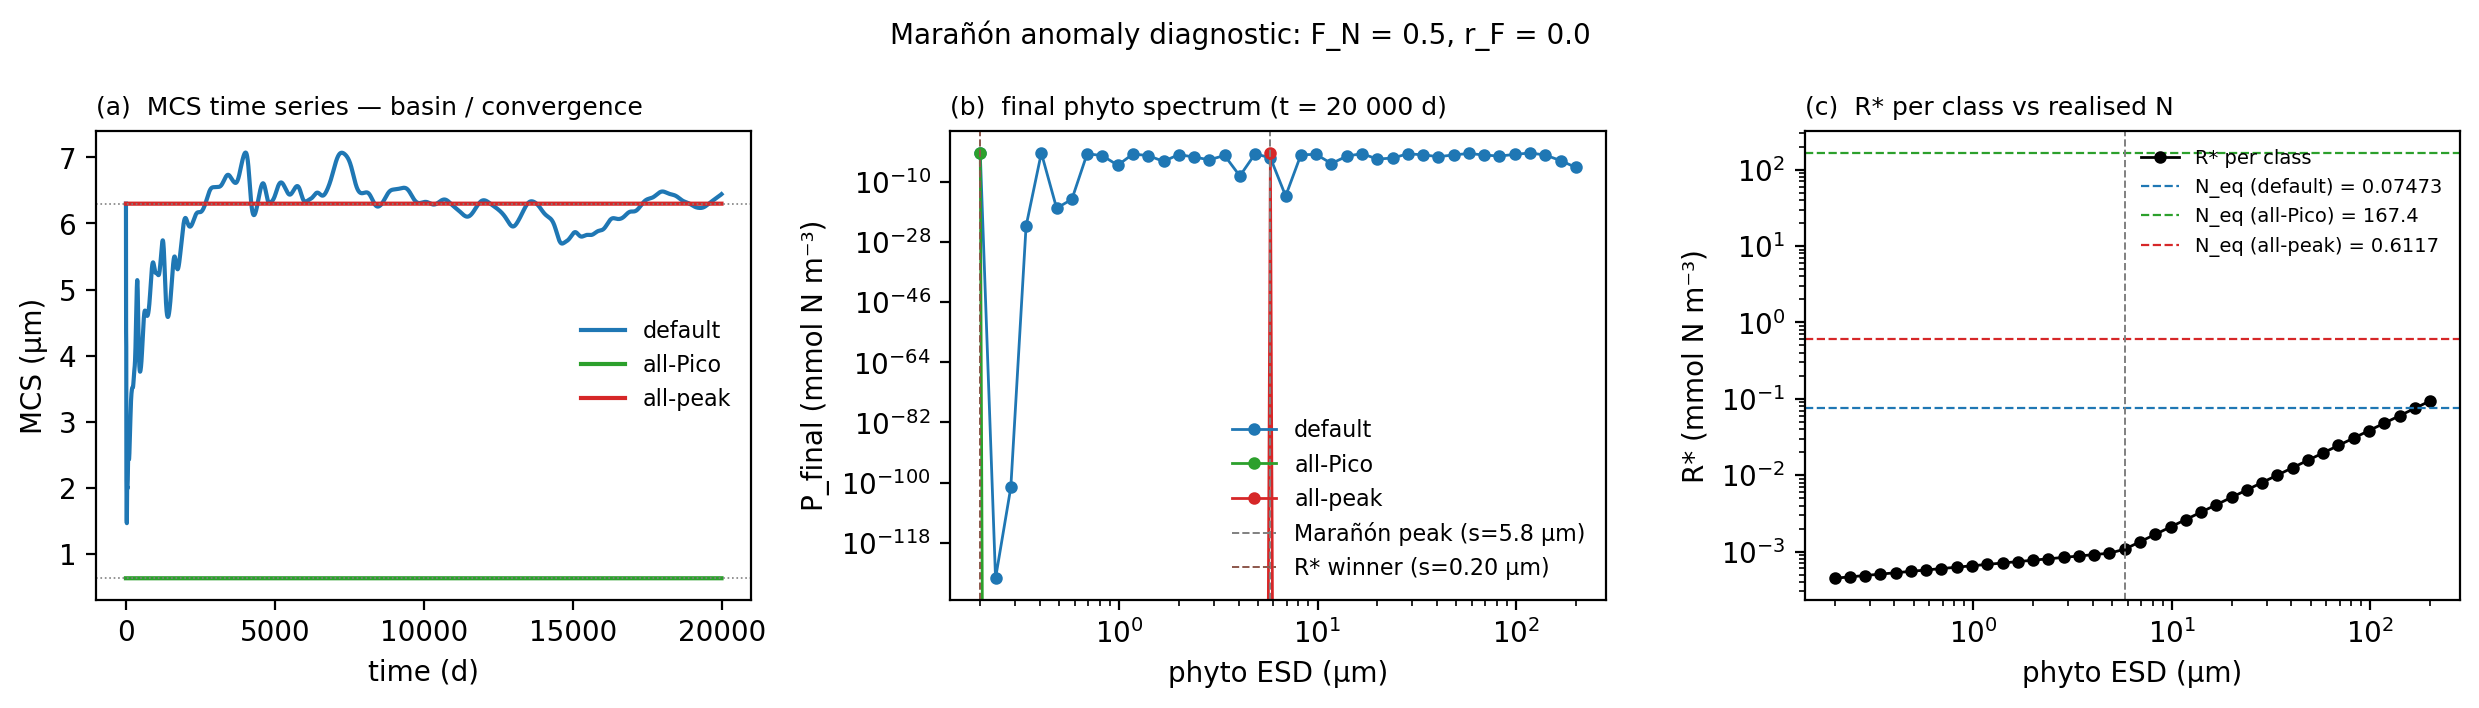


Theoretical R* winner: P[0]  s = 0.20 µm  R* = 4.4682e-04
R* at Marañón peak  P[19]: 1.0730e-03

default   : MCS_final =  6.44 µm  |  dominant = P[0] s= 0.20 µm  |  P_dom = 0.0518  |  N_eq = 0.0747
all-Pico  : MCS_final =  0.63 µm  |  dominant = P[0] s= 0.20 µm  |  P_dom = 0.0305  |  N_eq = 167.4273
all-peak  : MCS_final =  6.30 µm  |  dominant = P[19] s= 5.79 µm  |  P_dom = 0.0571  |  N_eq = 0.6117

--- verdict ---
MCS spread across ICs = 5.81 µm → MULTIPLE BASINS confirmed.
→ The (F_N=0.5, r_F=0) cell has at least two attractors; default IC
  lands in the peak-class basin; tiny r_F flips it. Manuscript-relevant.


In [13]:
%config InlineBackend.figure_format = 'retina'
import time as _t
import numpy as np, matplotlib.pyplot as plt
import xso
import parscan_utils_extended as pue
import seasonal_scan_harness as ssh
from baseline_r0_setups import (
    model_baseline, make_baseline_input_vars, SLIM_OUTPUT_VARS,
    phyto_esd, phyto_init,
)

# --- anomaly cell: lowest F_N + zero fish ---
FN0, RF0, DE0, T0 = 0.5, 0.0, 50.0, 20.0
spec = ssh.allometry('maranon_ward')
mu_max_arr, ks_arr = spec['mu_max'], spec['halfsat']
P_total_init = float(np.sum(phyto_init))
i_peak = int(np.argmax(mu_max_arr))   # Marañón peak class
print(f"Marañón peak: P[{i_peak}] s = {phyto_esd[i_peak]:.2f} µm "
      f"(μ_max = {mu_max_arr[i_peak]:.3f} d⁻¹)\n")

# --- three initial conditions ---
ic_default = phyto_init.copy()
ic_all_pico = np.zeros_like(phyto_init); ic_all_pico[0]     = P_total_init
ic_all_peak = np.zeros_like(phyto_init); ic_all_peak[i_peak] = P_total_init
ic_variants = {'default':   ic_default,
               'all-Pico':  ic_all_pico,
               'all-peak':  ic_all_peak}

# --- long IVP, 20000 d, tight tols, coarsened t_eval (5-d) ---
T_END   = 20000.0
time_ax = np.arange(0.0, T_END, 5.0)
SK = {'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-6,
      'max_step': 1.0, 'instability_neg_threshold': -1e-3}

results = {}
for label, ic in ic_variants.items():
    iv = make_baseline_input_vars(
        fish_rate=RF0, FN=FN0, de=DE0, T=T0,
        mu_max=mu_max_arr, halfsat=ks_arr, mP=0.0015, m_Z=0.1,
    )
    iv['Phytoplankton']['biomass_init'] = ic
    iv['Grazing']['KsZ']       = 0.23
    iv['Grazing']['sigma_log'] = 0.20
    iv['GrazingRouter']['gge'] = 0.31
    setup = xso.setup(solver='solve_ivp', model=model_baseline, time=time_ax,
                      input_vars=iv, output_vars=SLIM_OUTPUT_VARS, solver_kwargs=SK)
    t0 = _t.perf_counter()
    out = pue.run_single_point(model_baseline, setup, {})
    print(f"{label:10s} wall {_t.perf_counter()-t0:.1f}s  "
          f"reached t = {out['time'].values[-1]:.0f} d")
    results[label] = out

# --- derived series ---
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
W    = pue.compute_sieburth_weights(phyto_esd)

# --- theoretical R* per class (at T_REF, Q10 factor = 1) ---
mP = 0.0015
R_star = mP * ks_arr / np.maximum(mu_max_arr - mP, 1e-12)
i_R_winner = int(np.argmin(R_star))

# --- 3-panel diagnostic plot ---
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
colors = {'default': 'C0', 'all-Pico': 'C2', 'all-peak': 'C3'}

for label, out in results.items():
    P = out['Phytoplankton__biomass'].transpose('phyto', 'time').values
    t = out['time'].values
    bins = W @ P; sb = bins.sum(0)
    fr = np.divide(bins, sb, out=np.full_like(bins, np.nan), where=sb > 0)
    mcs = 10 ** (np.log10(GEOM) @ fr)
    axes[0].plot(t, mcs, lw=1.5, color=colors[label], label=label)
    # final spectrum
    axes[1].plot(phyto_esd, P[:, -1], 'o-', ms=3.5, lw=1.0,
                 color=colors[label], label=label)

axes[0].set_xlabel('time (d)'); axes[0].set_ylabel('MCS (µm)')
axes[0].set_title('(a)  MCS time series — basin / convergence', fontsize=9, loc='left')
axes[0].axhline(0.63, color='0.5', ls=':', lw=0.6); axes[0].axhline(6.3, color='0.5', ls=':', lw=0.6)
axes[0].legend(fontsize=8, frameon=False)

axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('phyto ESD (µm)'); axes[1].set_ylabel('P_final (mmol N m⁻³)')
axes[1].set_title('(b)  final phyto spectrum (t = 20 000 d)', fontsize=9, loc='left')
axes[1].axvline(phyto_esd[i_peak], color='0.5', ls='--', lw=0.7,
                label=f'Marañón peak (s={phyto_esd[i_peak]:.1f} µm)')
axes[1].axvline(phyto_esd[i_R_winner], color='C5', ls='--', lw=0.7,
                label=f'R* winner (s={phyto_esd[i_R_winner]:.2f} µm)')
axes[1].legend(fontsize=8, frameon=False)

axes[2].plot(phyto_esd, R_star, 'o-', ms=3.5, lw=1.0, color='k', label='R* per class')
for label, out in results.items():
    N_eq = float(out['Nutrient__value'].values[-1])
    axes[2].axhline(N_eq, color=colors[label], ls='--', lw=0.8,
                    label=f'N_eq ({label}) = {N_eq:.4g}')
axes[2].set_xscale('log'); axes[2].set_yscale('log')
axes[2].set_xlabel('phyto ESD (µm)'); axes[2].set_ylabel('R* (mmol N m⁻³)')
axes[2].set_title('(c)  R* per class vs realised N', fontsize=9, loc='left')
axes[2].axvline(phyto_esd[i_peak], color='0.5', ls='--', lw=0.7)
axes[2].legend(fontsize=7, frameon=False)

fig.suptitle(f'Marañón anomaly diagnostic: F_N = {FN0}, r_F = {RF0}', fontsize=10)
fig.tight_layout(); plt.show()

# --- numeric read-off + verdict ---
print(f"\nTheoretical R* winner: P[{i_R_winner}]  s = {phyto_esd[i_R_winner]:.2f} µm  "
      f"R* = {R_star[i_R_winner]:.4e}")
print(f"R* at Marañón peak  P[{i_peak}]: {R_star[i_peak]:.4e}\n")
mcs_finals = {}
for label, out in results.items():
    P_final = out['Phytoplankton__biomass'].transpose('phyto', 'time').values[:, -1]
    N_eq    = float(out['Nutrient__value'].values[-1])
    i_dom   = int(np.argmax(P_final))
    bins    = W @ P_final.reshape(-1, 1)
    fr      = bins / max(bins.sum(), 1e-12)
    mcs_f   = float(10 ** (np.log10(GEOM) @ fr.flatten()))
    mcs_finals[label] = mcs_f
    print(f"{label:10s}: MCS_final = {mcs_f:5.2f} µm  |  dominant = P[{i_dom}] "
          f"s={phyto_esd[i_dom]:5.2f} µm  |  P_dom = {P_final[i_dom]:.4f}  |  N_eq = {N_eq:.4f}")

print("\n--- verdict ---")
spread = max(mcs_finals.values()) - min(mcs_finals.values())
if spread > 0.5:
    print(f"MCS spread across ICs = {spread:.2f} µm → MULTIPLE BASINS confirmed.")
    print("→ The (F_N=0.5, r_F=0) cell has at least two attractors; default IC")
    print("  lands in the peak-class basin; tiny r_F flips it. Manuscript-relevant.")
else:
    print(f"MCS spread across ICs = {spread:.2f} µm → SINGLE ATTRACTOR.")
    print("→ All ICs converge to the same state. Either Marañón unimodal μ truly")
    print("  selects the peak class at low N (check whether realised N stays above")
    print("  the R*-winner's break-even on (c)), or 20000 d is still too short.")

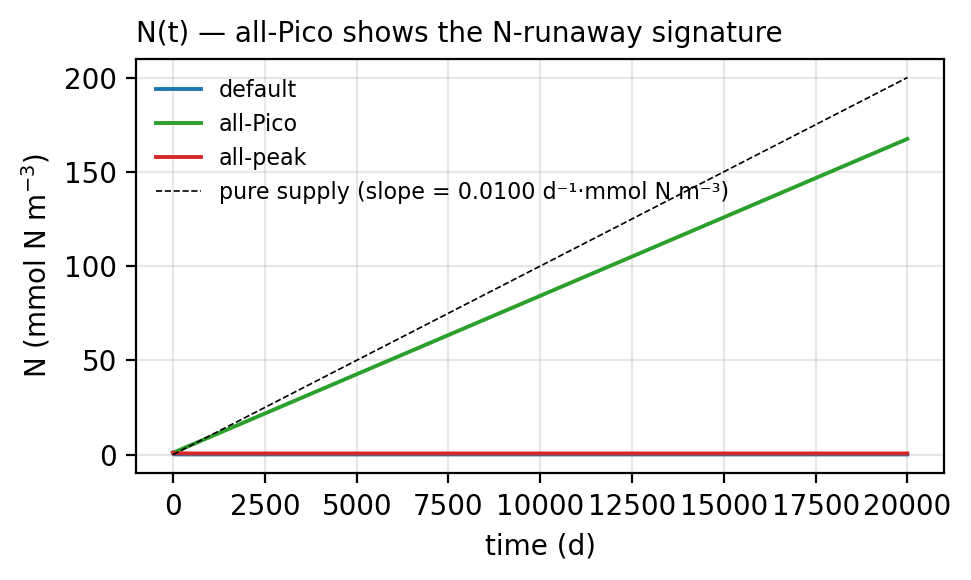

N final values: default=0.075, all-Pico=167.427, all-peak=0.612
Pure-supply N(t=20000) would be: 200.000


In [14]:
fig, ax = plt.subplots(figsize=(5, 3))
for label, out in results.items():
    ax.plot(out['time'].values, out['Nutrient__value'].values, lw=1.4,
            color={'default':'C0','all-Pico':'C2','all-peak':'C3'}[label], label=label)
ax.set_xlabel('time (d)'); ax.set_ylabel('N (mmol N m$^{-3}$)')
ax.set_title('N(t) — all-Pico shows the N-runaway signature', fontsize=10, loc='left')
# annotate the supply rate
supply = 0.5 / 50.0    # F_N / d_e
ax.plot([0, 20000], [0, supply*20000], 'k--', lw=0.6,
        label=f'pure supply (slope = {supply:.4f} d⁻¹·mmol N m⁻³)')
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"N final values: default={results['default']['Nutrient__value'].values[-1]:.3f}, "
      f"all-Pico={results['all-Pico']['Nutrient__value'].values[-1]:.3f}, "
      f"all-peak={results['all-peak']['Nutrient__value'].values[-1]:.3f}")
print(f"Pure-supply N(t=20000) would be: {supply*20000:.3f}")

In [ ]:
import time as _t, numpy as np, os
import xarray as xr
from xso.parscans import run_xso_parscan
import seasonal_scan_harness as ssh

# --- high-res axes; F_N extended down to 0.1 to capture low-N anomaly ---
FN_HI = np.linspace(0.1, 6.0, 50)
RF_HI = np.linspace(0.0, 0.6, 50)
print(f"axes: F_N {FN_HI[0]:.2f}–{FN_HI[-1]:.2f} (Δ={FN_HI[1]-FN_HI[0]:.3f}, n={len(FN_HI)})  |  "
      f"r_F {RF_HI[0]:.2f}–{RF_HI[-1]:.2f} (Δ={RF_HI[1]-RF_HI[0]:.4f}, n={len(RF_HI)})")
print(f"cells: {len(FN_HI)*len(RF_HI)} = 2500\n")

# --- construct overrides (same as the 14×7 preview + smoke test) ---
spec = ssh.allometry('maranon_ward')
fixed_hi = {
    'Inflow__de':             50.0,
    'Temperature__value':     20.0,
    'Growth__mu_max':         spec['mu_max'],
    'Growth__halfsat':        spec['halfsat'],
    'PhytoMortality__rate':   0.0015,
    'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ':           0.23,
    'Grazing__sigma_log':     0.20,
    'GrazingRouter__gge':     0.31,
}

# --- run ---
t0 = _t.perf_counter()
scan_hi = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim_tight',
    param_name='Inflow__FN',         param_values=FN_HI,
    param_name2='FishGrazing__rate', param_values2=RF_HI,
    fixed_overrides=fixed_hi,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,        # Mac Studio: bump to physical core count if desired
)
wall = (_t.perf_counter() - t0) / 60
print(f"\nwall: {wall:.1f} min")

# --- summary ---
n_trip = int(scan_hi['tail_has_nan'].sum().item())
cv_max = float(scan_hi['cv_sumP'].max().item())
n_size = int(scan_hi['cv_sumP'].size)
print(f"trips: {n_trip}/{n_size}  |  cv_sumP max: {cv_max:.4f}  "
      f"(>0.10 in {int((scan_hi['cv_sumP'] > 0.10).sum().item())} cells)")

# --- save to netCDF; drop object-dtype vars (the constant arrays from fixed_overrides) ---
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_ss_scan_50x50_2026-06-24.nc')
to_save = scan_hi.drop_vars([v for v in scan_hi.data_vars if scan_hi[v].dtype == object])
to_save.attrs.update(dict(
    construct='maranon_ward',
    GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
    de=50.0, T=20.0,
    forcing='SS, decoupled (T = T_REF = 20°C → Q10 factor = 1; de = 50 m)',
    solver='setup_baseline_slim_tight (RK45, atol=1e-9, rtol=1e-6, max_step=1.0)',
    FN_range='linear 0.1–6.0, 50 pts (extended down to 0.1 to portrait low-N anomaly)',
    rF_range='linear 0.0–0.6, 50 pts',
    created='2026-06-24',
    notes='2500-cell SS map for Fig 5; see project_solver_tolerances.md and the '
          '"Cycle-Boundary Approach" entry in Ideas and Findings.md for the solver '
          'and dynamical-regime context.',
))
to_save.to_netcdf(nc_path)
size_mb = os.path.getsize(nc_path) / 1e6
print(f"\nsaved: {nc_path}  ({size_mb:.1f} MB)")
print(f"reload later with: scan_hi = xr.open_dataset('{nc_path}')")